# 02 - EDA Report: Southeast Asia Rainfall Dataset

Goal: transform the raw multi-source rainfall dataset into an evidence-driven exploratory report.

Analytical storyline:
1. Define every feature before any statistic is interpreted.
2. Validate completeness and physical plausibility.
3. Engineer rainfall, seasonality, anomaly, spell, and source-uncertainty features.
4. Compare cities, months, years, and weather regimes.
5. Audit NASA POWER vs Open-Meteo disagreement at daily, monthly, and spatial levels.
6. Place the results on a real Southeast Asia map with country borders and coastlines.


## Inputs and Report Outputs

Input files:
- `data/raw/sea_rainfall_daily_2020_2025_entity_resolved.csv`
- `data/raw/sea_rainfall_daily_2020_2025_entity_registry.csv`
- `data/raw/sea_rainfall_daily_2020_2025_source_observations.csv`
- `data/raw/sea_rainfall_daily_2020_2025_manifest.json`

Report output folder:
- `reports/02_EDA_report/figures/`
- `reports/02_EDA_report/tables/`

Figures are saved at publication-oriented resolution and use descriptive filenames so they can be dropped into the written report.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY_AVAILABLE = True
except Exception as error:
    CARTOPY_AVAILABLE = False
    CARTOPY_IMPORT_ERROR = repr(error)

try:
    display
except NameError:
    def display(obj):
        if hasattr(obj, 'to_string'):
            print(obj.to_string())
        else:
            print(obj)

warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
REPORT_DIR = PROJECT_ROOT / 'reports' / '02_EDA_report'
FIGURE_DIR = REPORT_DIR / 'figures'
TABLE_DIR = REPORT_DIR / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RESOLVED_PATH = RAW_DIR / 'sea_rainfall_daily_2020_2025_entity_resolved.csv'
REGISTRY_PATH = RAW_DIR / 'sea_rainfall_daily_2020_2025_entity_registry.csv'
SOURCE_OBSERVATIONS_PATH = RAW_DIR / 'sea_rainfall_daily_2020_2025_source_observations.csv'
MANIFEST_PATH = RAW_DIR / 'sea_rainfall_daily_2020_2025_manifest.json'

MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
SOURCE_COLORS = {'NASA POWER': '#0072B2', 'Open-Meteo': '#D55E00'}

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.linewidth': 0.7,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#222222',
    'ytick.color': '#222222',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family': 'DejaVu Sans',
})

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved figure: {path.relative_to(PROJECT_ROOT)}')


def save_table(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table: {path.relative_to(PROJECT_ROOT)}')


def add_title(fig, title, subtitle=None):
    fig.suptitle(title, fontsize=15, fontweight='bold', x=0.01, ha='left', y=1.02)
    if subtitle:
        fig.text(0.01, 0.965, subtitle, fontsize=10.5, color='#444444', ha='left')


def add_source_note(fig, note='Source: NASA POWER and Open-Meteo, daily observations resolved by entity_id + date.'):
    fig.text(0.01, -0.02, note, fontsize=8.5, color='#555555', ha='left')


print(f'Project root: {PROJECT_ROOT}')
print(f'Report directory: {REPORT_DIR}')
print(f'Cartopy available: {CARTOPY_AVAILABLE}')
if not CARTOPY_AVAILABLE:
    print(f'Cartopy import error: {CARTOPY_IMPORT_ERROR}')


Project root: D:\DS\Project
Report directory: D:\DS\Project\reports\02_EDA_report
Cartopy available: True


In [2]:
resolved_df = pd.read_csv(RESOLVED_PATH, parse_dates=['date'])
registry_df = pd.read_csv(REGISTRY_PATH)
source_df = pd.read_csv(SOURCE_OBSERVATIONS_PATH, parse_dates=['date'])

with MANIFEST_PATH.open('r', encoding='utf-8') as file:
    manifest = json.load(file)

resolved_df = resolved_df.sort_values(['entity_id', 'date']).reset_index(drop=True)
source_df = source_df.sort_values(['source', 'entity_id', 'date']).reset_index(drop=True)

print('Resolved dataset shape:', resolved_df.shape)
print('Source observations shape:', source_df.shape)
print('Entity registry shape:', registry_df.shape)
print('Manifest row counts:', manifest.get('row_counts'))
display(resolved_df.head())


Resolved dataset shape: (26304, 22)
Source observations shape: (52608, 19)
Entity registry shape: (12, 15)
Manifest row counts: {'entity_registry_rows': 12, 'entity_resolved_rows': 26304, 'raw_api_requests': 24, 'source_observations': 52608}


,entity_id,date,country,location_name,canonical_latitude,canonical_longitude,nasa_power_precipitation_mm,nasa_power_temp_mean_c,nasa_power_temp_max_c,nasa_power_temp_min_c,...,nasa_power_surface_pressure_kpa,open_meteo_precipitation_mm,open_meteo_temp_mean_c,open_meteo_temp_max_c,open_meteo_temp_min_c,open_meteo_relative_humidity_pct,open_meteo_wind_speed_ms,open_meteo_surface_pressure_kpa,precipitation_mm_mean_two_sources,precipitation_mm_abs_diff
0,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-01,Brunei,Bandar Seri Begawan,4.9031,114.9398,2.29,27.59,29.24,26.03,...,100.70,1.1,27.1,30.0,23.7,85.0,2.5833,101.07,1.695,1.19
1,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-02,Brunei,Bandar Seri Begawan,4.9031,114.9398,1.17,27.46,29.20,25.72,...,100.79,1.4,26.9,29.4,24.7,87.0,2.1944,101.09,1.285,0.23
2,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-03,Brunei,Bandar Seri Begawan,4.9031,114.9398,4.84,27.33,28.77,26.13,...,100.68,1.9,26.7,28.8,24.6,88.0,2.0556,100.96,3.370,2.94
3,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-04,Brunei,Bandar Seri Begawan,4.9031,114.9398,2.77,27.18,28.73,25.57,...,100.53,0.5,27.2,29.2,25.0,85.0,3.3889,100.76,1.635,2.27
4,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-05,Brunei,Bandar Seri Begawan,4.9031,114.9398,0.46,27.45,29.45,25.61,...,100.51,8.6,26.8,30.0,24.3,87.0,1.5833,100.81,4.530,8.14


## 1. Feature Dictionary Before Interpretation

The report starts with a feature dictionary because rainfall analysis becomes fragile if units, lineage, and derived columns are unclear. This table separates canonical identifiers, source-specific measurements, and engineered EDA features.

In [3]:
base_feature_specs = [
    ('entity_id', 'Identifier', 'Canonical real-world location after entity resolution.', 'None', 'Canonical'),
    ('date', 'Time key', 'Daily observation date.', 'YYYY-MM-DD', 'Canonical'),
    ('country', 'Descriptor', 'Country of the canonical location.', 'None', 'Canonical'),
    ('location_name', 'Descriptor', 'City or capital name.', 'None', 'Canonical'),
    ('canonical_latitude', 'Coordinate', 'Latitude used to define the canonical entity.', 'Decimal degrees', 'Canonical'),
    ('canonical_longitude', 'Coordinate', 'Longitude used to define the canonical entity.', 'Decimal degrees', 'Canonical'),
    ('nasa_power_precipitation_mm', 'Weather', 'NASA POWER corrected daily precipitation.', 'mm/day', 'NASA POWER'),
    ('nasa_power_temp_mean_c', 'Weather', 'NASA POWER daily mean air temperature at 2 meters.', 'C', 'NASA POWER'),
    ('nasa_power_temp_max_c', 'Weather', 'NASA POWER daily maximum air temperature at 2 meters.', 'C', 'NASA POWER'),
    ('nasa_power_temp_min_c', 'Weather', 'NASA POWER daily minimum air temperature at 2 meters.', 'C', 'NASA POWER'),
    ('nasa_power_relative_humidity_pct', 'Weather', 'NASA POWER relative humidity at 2 meters.', 'Percent', 'NASA POWER'),
    ('nasa_power_wind_speed_ms', 'Weather', 'NASA POWER wind speed at 2 meters.', 'm/s', 'NASA POWER'),
    ('nasa_power_surface_pressure_kpa', 'Weather', 'NASA POWER surface pressure.', 'kPa', 'NASA POWER'),
    ('open_meteo_precipitation_mm', 'Weather', 'Open-Meteo daily precipitation sum.', 'mm/day', 'Open-Meteo'),
    ('open_meteo_temp_mean_c', 'Weather', 'Open-Meteo daily mean air temperature at 2 meters.', 'C', 'Open-Meteo'),
    ('open_meteo_temp_max_c', 'Weather', 'Open-Meteo daily maximum air temperature at 2 meters.', 'C', 'Open-Meteo'),
    ('open_meteo_temp_min_c', 'Weather', 'Open-Meteo daily minimum air temperature at 2 meters.', 'C', 'Open-Meteo'),
    ('open_meteo_relative_humidity_pct', 'Weather', 'Open-Meteo daily mean relative humidity at 2 meters.', 'Percent', 'Open-Meteo'),
    ('open_meteo_wind_speed_ms', 'Weather', 'Open-Meteo wind speed converted from km/h to m/s.', 'm/s', 'Open-Meteo standardized'),
    ('open_meteo_surface_pressure_kpa', 'Weather', 'Open-Meteo pressure converted from hPa to kPa.', 'kPa', 'Open-Meteo standardized'),
    ('precipitation_mm_mean_two_sources', 'Derived', 'Mean of NASA POWER and Open-Meteo precipitation for the same entity-date.', 'mm/day', 'Notebook 01'),
    ('precipitation_mm_abs_diff', 'Derived quality metric', 'Absolute precipitation gap between NASA POWER and Open-Meteo.', 'mm/day', 'Notebook 01'),
]

engineered_feature_specs = [
    ('rainfall_mm', 'Engineered rainfall target', 'Alias of the two-source mean precipitation used as the main EDA rainfall measure.', 'mm/day', 'Notebook 02'),
    ('source_bias_mm', 'Source uncertainty', 'NASA POWER precipitation minus Open-Meteo precipitation.', 'mm/day', 'Notebook 02'),
    ('source_abs_diff_mm', 'Source uncertainty', 'Absolute daily difference between the two rainfall sources.', 'mm/day', 'Notebook 02'),
    ('source_relative_abs_diff', 'Source uncertainty', 'Absolute source gap divided by rainfall amount plus one to control scale effects.', 'Ratio', 'Notebook 02'),
    ('wet_day', 'Rainfall regime', 'Day with rainfall at least 1 mm.', 'Boolean', 'Notebook 02'),
    ('moderate_rain_day', 'Rainfall regime', 'Day with rainfall at least 10 mm.', 'Boolean', 'Notebook 02'),
    ('heavy_rain_day', 'Rainfall regime', 'Day with rainfall at least 20 mm.', 'Boolean', 'Notebook 02'),
    ('extreme_rain_day', 'Rainfall regime', 'Day with rainfall at least 50 mm.', 'Boolean', 'Notebook 02'),
    ('rainfall_lag_1d', 'Temporal feature', 'Previous day rainfall within the same entity.', 'mm/day', 'Notebook 02'),
    ('rainfall_lag_7d', 'Temporal feature', 'Rainfall seven days earlier within the same entity.', 'mm/day', 'Notebook 02'),
    ('rainfall_rolling_7d_mean', 'Temporal feature', 'Seven-day rolling mean rainfall within the same entity.', 'mm/day', 'Notebook 02'),
    ('rainfall_rolling_30d_sum', 'Temporal feature', 'Thirty-day rolling rainfall accumulation within the same entity.', 'mm/30 days', 'Notebook 02'),
    ('rainfall_rolling_90d_mean', 'Temporal feature', 'Ninety-day rolling mean rainfall within the same entity.', 'mm/day', 'Notebook 02'),
    ('rainfall_anomaly_mm', 'Climatology feature', 'Daily rainfall minus entity-month climatological daily rainfall.', 'mm/day', 'Notebook 02'),
    ('rainfall_zscore_city_month', 'Climatology feature', 'City-month standardized daily rainfall anomaly.', 'Standard deviations', 'Notebook 02'),
    ('rainfall_percentile_city', 'Distribution feature', 'Within-city percentile rank of daily rainfall.', '0-1 percentile', 'Notebook 02'),
    ('wet_spell_days', 'Spell feature', 'Current consecutive wet-day run length.', 'Days', 'Notebook 02'),
    ('dry_spell_days', 'Spell feature', 'Current consecutive dry-day run length.', 'Days', 'Notebook 02'),
    ('month_sin', 'Seasonality encoding', 'Sine encoding of month for cyclic seasonality.', 'Unitless', 'Notebook 02'),
    ('month_cos', 'Seasonality encoding', 'Cosine encoding of month for cyclic seasonality.', 'Unitless', 'Notebook 02'),
    ('season_quarter', 'Seasonality feature', 'DJF, MAM, JJA, or SON seasonal label.', 'Category', 'Notebook 02'),
]

feature_dictionary = pd.DataFrame(
    base_feature_specs + engineered_feature_specs,
    columns=['column_name', 'feature_group', 'meaning', 'unit_or_format', 'source_or_lineage'],
)
feature_dictionary['observed_dtype_before_engineering'] = feature_dictionary['column_name'].map(resolved_df.dtypes.astype(str)).fillna('created in this notebook')
feature_dictionary = feature_dictionary[
    ['column_name', 'observed_dtype_before_engineering', 'feature_group', 'unit_or_format', 'source_or_lineage', 'meaning']
]
save_table(feature_dictionary, '01_feature_dictionary.csv')
display(feature_dictionary)


Saved table: reports\02_EDA_report\tables\01_feature_dictionary.csv


,column_name,observed_dtype_before_engineering,feature_group,unit_or_format,source_or_lineage,meaning
0,entity_id,object,Identifier,None,Canonical,Canonical real-world location after entity res...
1,date,datetime64[ns],Time key,YYYY-MM-DD,Canonical,Daily observation date.
2,country,object,Descriptor,None,Canonical,Country of the canonical location.
3,location_name,object,Descriptor,None,Canonical,City or capital name.
4,canonical_latitude,float64,Coordinate,Decimal degrees,Canonical,Latitude used to define the canonical entity.
5,canonical_longitude,float64,Coordinate,Decimal degrees,Canonical,Longitude used to define the canonical entity.
6,nasa_power_precipitation_mm,float64,Weather,mm/day,NASA POWER,NASA POWER corrected daily precipitation.
7,nasa_power_temp_mean_c,float64,Weather,C,NASA POWER,NASA POWER daily mean air temperature at 2 met...
8,nasa_power_temp_max_c,float64,Weather,C,NASA POWER,NASA POWER daily maximum air temperature at 2 ...
9,nasa_power_temp_min_c,float64,Weather,C,NASA POWER,NASA POWER daily minimum air temperature at 2 ...


## 2. Feature Engineering for Rainfall Regimes and Source Uncertainty

The engineered features are designed for both EDA and later preprocessing. They make the dataset more analytically useful without overwriting the source-specific measurements.

In [4]:
eda_df = resolved_df.copy()
eda_df['year'] = eda_df['date'].dt.year
eda_df['month'] = eda_df['date'].dt.month
eda_df['month_name'] = eda_df['month'].map(lambda month: MONTH_LABELS[month - 1])
eda_df['year_month'] = eda_df['date'].dt.to_period('M').dt.to_timestamp()
eda_df['day_of_year'] = eda_df['date'].dt.dayofyear
eda_df['season_quarter'] = eda_df['month'].map({12: 'DJF', 1: 'DJF', 2: 'DJF', 3: 'MAM', 4: 'MAM', 5: 'MAM', 6: 'JJA', 7: 'JJA', 8: 'JJA', 9: 'SON', 10: 'SON', 11: 'SON'})
eda_df['month_sin'] = np.sin(2 * np.pi * eda_df['month'] / 12)
eda_df['month_cos'] = np.cos(2 * np.pi * eda_df['month'] / 12)

eda_df['rainfall_mm'] = eda_df['precipitation_mm_mean_two_sources']
eda_df['source_bias_mm'] = eda_df['nasa_power_precipitation_mm'] - eda_df['open_meteo_precipitation_mm']
eda_df['source_abs_diff_mm'] = eda_df['source_bias_mm'].abs()
eda_df['source_relative_abs_diff'] = eda_df['source_abs_diff_mm'] / (eda_df['rainfall_mm'] + 1.0)

eda_df['wet_day'] = eda_df['rainfall_mm'] >= 1.0
eda_df['moderate_rain_day'] = eda_df['rainfall_mm'] >= 10.0
eda_df['heavy_rain_day'] = eda_df['rainfall_mm'] >= 20.0
eda_df['extreme_rain_day'] = eda_df['rainfall_mm'] >= 50.0

def add_temporal_features(group):
    group = group.sort_values('date').copy()
    group['rainfall_lag_1d'] = group['rainfall_mm'].shift(1)
    group['rainfall_lag_7d'] = group['rainfall_mm'].shift(7)
    group['rainfall_rolling_7d_mean'] = group['rainfall_mm'].rolling(7, min_periods=3).mean()
    group['rainfall_rolling_30d_sum'] = group['rainfall_mm'].rolling(30, min_periods=10).sum()
    group['rainfall_rolling_90d_mean'] = group['rainfall_mm'].rolling(90, min_periods=30).mean()

    wet = group['wet_day'].astype(bool)
    dry = ~wet
    wet_groups = (wet != wet.shift()).cumsum()
    dry_groups = (dry != dry.shift()).cumsum()
    group['wet_spell_days'] = wet.groupby(wet_groups).cumcount() + 1
    group.loc[~wet, 'wet_spell_days'] = 0
    group['dry_spell_days'] = dry.groupby(dry_groups).cumcount() + 1
    group.loc[~dry, 'dry_spell_days'] = 0
    return group

eda_df = eda_df.groupby('entity_id', group_keys=False).apply(add_temporal_features).reset_index(drop=True)

climatology_daily = (
    eda_df.groupby(['entity_id', 'month'], as_index=False)
    .agg(
        city_month_mean_daily_rainfall_mm=('rainfall_mm', 'mean'),
        city_month_std_daily_rainfall_mm=('rainfall_mm', 'std'),
    )
)
eda_df = eda_df.merge(climatology_daily, on=['entity_id', 'month'], how='left')
eda_df['rainfall_anomaly_mm'] = eda_df['rainfall_mm'] - eda_df['city_month_mean_daily_rainfall_mm']
eda_df['rainfall_zscore_city_month'] = eda_df['rainfall_anomaly_mm'] / eda_df['city_month_std_daily_rainfall_mm'].replace(0, np.nan)
eda_df['rainfall_percentile_city'] = eda_df.groupby('entity_id')['rainfall_mm'].rank(pct=True)

engineered_preview_cols = [
    'entity_id', 'date', 'rainfall_mm', 'source_bias_mm', 'source_abs_diff_mm', 'wet_day',
    'heavy_rain_day', 'rainfall_lag_1d', 'rainfall_rolling_30d_sum', 'rainfall_anomaly_mm',
    'rainfall_zscore_city_month', 'wet_spell_days', 'dry_spell_days', 'month_sin', 'month_cos'
]
save_table(eda_df[engineered_preview_cols].head(200), '02_engineered_feature_preview_first_200_rows.csv')
display(eda_df[engineered_preview_cols].head())


Saved table: reports\02_EDA_report\tables\02_engineered_feature_preview_first_200_rows.csv


,entity_id,date,rainfall_mm,source_bias_mm,source_abs_diff_mm,wet_day,heavy_rain_day,rainfall_lag_1d,rainfall_rolling_30d_sum,rainfall_anomaly_mm,rainfall_zscore_city_month,wet_spell_days,dry_spell_days,month_sin,month_cos
0,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-01,1.695,1.19,1.19,True,False,NaN,NaN,-9.489839,-0.909334,1,0,0.5,0.866025
1,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-02,1.285,-0.23,0.23,True,False,1.695,NaN,-9.899839,-0.948621,2,0,0.5,0.866025
2,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-03,3.370,2.94,2.94,True,False,1.285,NaN,-7.814839,-0.748833,3,0,0.5,0.866025
3,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-04,1.635,2.27,2.27,True,False,3.370,NaN,-9.549839,-0.915084,4,0,0.5,0.866025
4,SEA_BN_BANDAR_SERI_BEGAWAN,2020-01-05,4.530,-8.14,8.14,True,False,1.635,NaN,-6.654839,-0.637679,5,0,0.5,0.866025


## 3. Data Quality Gate

Before reading patterns as climate signals, the report checks whether the analytical table has duplicate keys, missing values, and impossible rainfall values.

Saved table: reports\02_EDA_report\tables\03_quality_checks.csv


,check,value,expected,passed
0,resolved_entity_date_duplicate_rows,0,0,True
1,source_entity_date_duplicate_rows,0,0,True
2,resolved_rows,26304,26304,True
3,source_observation_rows,52608,52608,True
4,entities,12,12,True
5,negative_nasa_precipitation_rows,0,0,True
6,negative_open_meteo_precipitation_rows,0,0,True
7,negative_two_source_mean_rows,0,0,True


Saved table: reports\02_EDA_report\tables\04_missing_summary.csv


,column_name,missing_pct
42,rainfall_rolling_90d_mean,1.322993
41,rainfall_rolling_30d_sum,0.410584
39,rainfall_lag_7d,0.319343
40,rainfall_rolling_7d_mean,0.091241
38,rainfall_lag_1d,0.045620
4,canonical_latitude,0.000000
2,country,0.000000
3,location_name,0.000000
8,nasa_power_temp_max_c,0.000000
9,nasa_power_temp_min_c,0.000000


Saved figure: reports\02_EDA_report\figures\01_quality_missingness.png


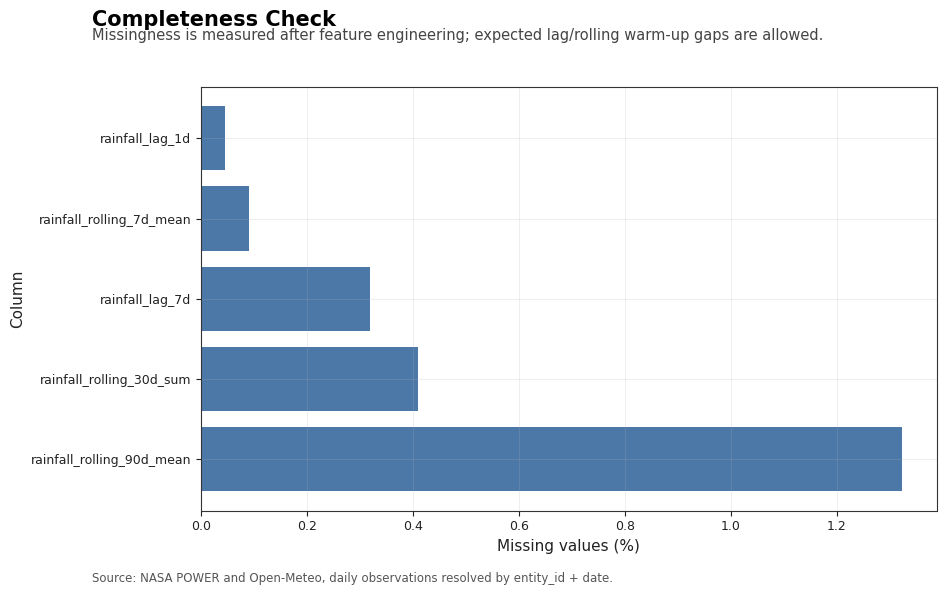

In [5]:
quality_checks = pd.DataFrame([
    {'check': 'resolved_entity_date_duplicate_rows', 'value': int(eda_df.duplicated(['entity_id', 'date']).sum()), 'expected': 0},
    {'check': 'source_entity_date_duplicate_rows', 'value': int(source_df.duplicated(['source', 'entity_id', 'date']).sum()), 'expected': 0},
    {'check': 'resolved_rows', 'value': int(len(eda_df)), 'expected': manifest['row_counts']['entity_resolved_rows']},
    {'check': 'source_observation_rows', 'value': int(len(source_df)), 'expected': manifest['row_counts']['source_observations']},
    {'check': 'entities', 'value': int(eda_df['entity_id'].nunique()), 'expected': manifest['row_counts']['entity_registry_rows']},
    {'check': 'negative_nasa_precipitation_rows', 'value': int((eda_df['nasa_power_precipitation_mm'] < 0).sum()), 'expected': 0},
    {'check': 'negative_open_meteo_precipitation_rows', 'value': int((eda_df['open_meteo_precipitation_mm'] < 0).sum()), 'expected': 0},
    {'check': 'negative_two_source_mean_rows', 'value': int((eda_df['rainfall_mm'] < 0).sum()), 'expected': 0},
])
quality_checks['passed'] = quality_checks['value'] == quality_checks['expected']
save_table(quality_checks, '03_quality_checks.csv')
display(quality_checks)

missing_summary = (
    eda_df.isna().mean()
    .mul(100)
    .rename('missing_pct')
    .reset_index()
    .rename(columns={'index': 'column_name'})
    .sort_values('missing_pct', ascending=False)
)
save_table(missing_summary, '04_missing_summary.csv')
display(missing_summary.head(20))

fig, ax = plt.subplots(figsize=(9.5, 5.5))
plot_data = missing_summary[missing_summary['missing_pct'] > 0]
if len(plot_data) == 0:
    ax.text(0.5, 0.5, 'No missing values detected in analytical columns', ha='center', va='center', fontsize=13)
    ax.set_axis_off()
else:
    ax.barh(plot_data['column_name'], plot_data['missing_pct'], color='#4C78A8')
    ax.set_xlabel('Missing values (%)')
    ax.set_ylabel('Column')
add_title(fig, 'Completeness Check', 'Missingness is measured after feature engineering; expected lag/rolling warm-up gaps are allowed.')
add_source_note(fig)
save_figure(fig, '01_quality_missingness.png')
plt.show()


## 4. City-Level Rainfall: Where Is Rain Concentrated?

This section compares cities using total rainfall, average daily rainfall, wet-day frequency, heavy-rain frequency, and source uncertainty. The purpose is not just ranking cities, but identifying where the dataset is most information-rich and where source disagreement could matter downstream.

Saved table: reports\02_EDA_report\tables\05_city_rainfall_summary.csv


,entity_id,country,location_name,observation_days,mean_daily_precip_mm,median_daily_precip_mm,p95_daily_precip_mm,total_precip_2020_2025_mm,wet_day_ratio,heavy_rain_day_ratio,extreme_rain_day_count,longest_wet_spell_days,longest_dry_spell_days,mean_source_abs_diff_mm
7,SEA_SG_SINGAPORE,Singapore,Singapore,2192,11.319197,7.7450,35.10450,24811.680,0.918796,0.141423,42,136,8,10.455164
0,SEA_BN_BANDAR_SERI_BEGAWAN,Brunei,Bandar Seri Begawan,2192,10.121775,6.9550,29.15900,22186.930,0.881843,0.131843,25,129,8,7.841250
6,SEA_PH_MANILA,Philippines,Manila,2192,8.187078,4.3375,27.47950,17946.075,0.809763,0.083029,43,121,15,7.132605
5,SEA_MY_KUALA_LUMPUR,Malaysia,Kuala Lumpur,2192,8.097083,5.5425,24.46675,17748.805,0.857664,0.086679,8,110,8,6.863271
1,SEA_ID_JAKARTA,Indonesia,Jakarta,2192,6.861797,4.7050,20.53400,15041.060,0.829380,0.054745,4,195,22,5.425246
4,SEA_MM_YANGON,Myanmar,Yangon,2192,6.627286,1.6100,26.15450,14527.010,0.525547,0.088504,10,164,108,5.875347
10,SEA_VN_HANOI,Vietnam,Hanoi,2192,5.674275,1.1400,25.62000,12438.010,0.520529,0.077099,26,34,44,4.749845
11,SEA_VN_HO_CHI_MINH,Vietnam,Ho Chi Minh City,2192,5.662267,2.9075,19.43225,12411.690,0.613595,0.046533,3,121,104,4.910593
2,SEA_KH_PHNOM_PENH,Cambodia,Phnom Penh,2192,5.019457,2.0725,19.18250,11002.650,0.591241,0.043796,3,95,76,5.015301
3,SEA_LA_VIENTIANE,Laos,Vientiane,2192,4.911453,0.9125,20.46825,10765.905,0.493157,0.052920,4,66,110,3.877395


Saved figure: reports\02_EDA_report\figures\02_city_total_rainfall_ranked.png


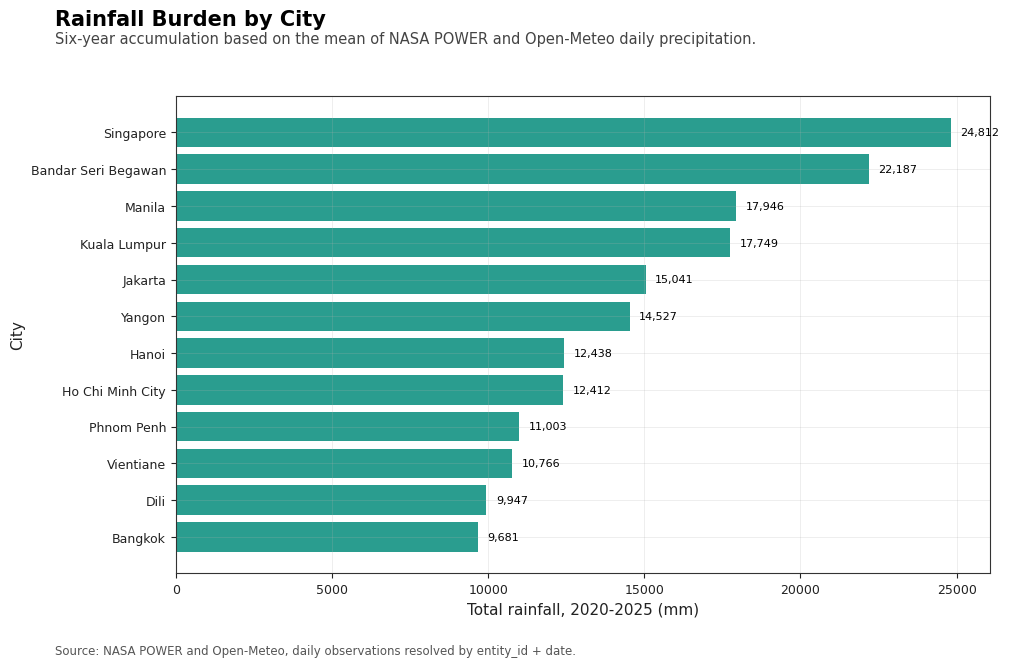

Saved figure: reports\02_EDA_report\figures\03_city_wet_and_heavy_day_frequency.png


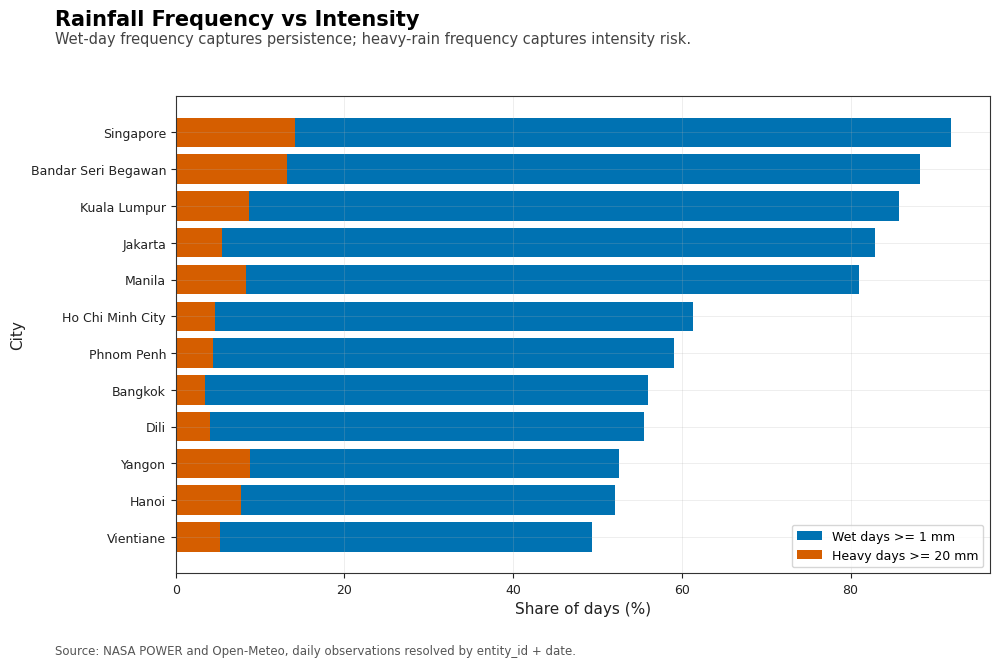

In [6]:
city_summary = (
    eda_df.groupby(['entity_id', 'country', 'location_name'], as_index=False)
    .agg(
        observation_days=('date', 'nunique'),
        mean_daily_precip_mm=('rainfall_mm', 'mean'),
        median_daily_precip_mm=('rainfall_mm', 'median'),
        p95_daily_precip_mm=('rainfall_mm', lambda s: s.quantile(0.95)),
        total_precip_2020_2025_mm=('rainfall_mm', 'sum'),
        wet_day_ratio=('wet_day', 'mean'),
        heavy_rain_day_ratio=('heavy_rain_day', 'mean'),
        extreme_rain_day_count=('extreme_rain_day', 'sum'),
        longest_wet_spell_days=('wet_spell_days', 'max'),
        longest_dry_spell_days=('dry_spell_days', 'max'),
        mean_source_abs_diff_mm=('source_abs_diff_mm', 'mean'),
    )
    .sort_values('total_precip_2020_2025_mm', ascending=False)
)
save_table(city_summary, '05_city_rainfall_summary.csv')
display(city_summary)

fig, ax = plt.subplots(figsize=(10.5, 6.2))
ordered = city_summary.sort_values('total_precip_2020_2025_mm', ascending=True)
bars = ax.barh(ordered['location_name'], ordered['total_precip_2020_2025_mm'], color='#2A9D8F')
ax.set_xlabel('Total rainfall, 2020-2025 (mm)')
ax.set_ylabel('City')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 300, bar.get_y() + bar.get_height() / 2, f'{width:,.0f}', va='center', fontsize=8)
add_title(fig, 'Rainfall Burden by City', 'Six-year accumulation based on the mean of NASA POWER and Open-Meteo daily precipitation.')
add_source_note(fig)
save_figure(fig, '02_city_total_rainfall_ranked.png')
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 6.2))
ordered = city_summary.sort_values('wet_day_ratio', ascending=True)
ax.barh(ordered['location_name'], ordered['wet_day_ratio'] * 100, color='#0072B2', label='Wet days >= 1 mm')
ax.barh(ordered['location_name'], ordered['heavy_rain_day_ratio'] * 100, color='#D55E00', label='Heavy days >= 20 mm')
ax.set_xlabel('Share of days (%)')
ax.set_ylabel('City')
ax.legend(loc='lower right')
add_title(fig, 'Rainfall Frequency vs Intensity', 'Wet-day frequency captures persistence; heavy-rain frequency captures intensity risk.')
add_source_note(fig)
save_figure(fig, '03_city_wet_and_heavy_day_frequency.png')
plt.show()


## 5. Distribution Shape: Rainfall Is Sparse, Skewed, and Regime-Based

Rainfall distributions are usually right-skewed: many low-rain days and a small number of high-impact wet days. This matters for preprocessing because mean-based summaries can hide extremes.

Saved figure: reports\02_EDA_report\figures\04_daily_rainfall_distribution.png


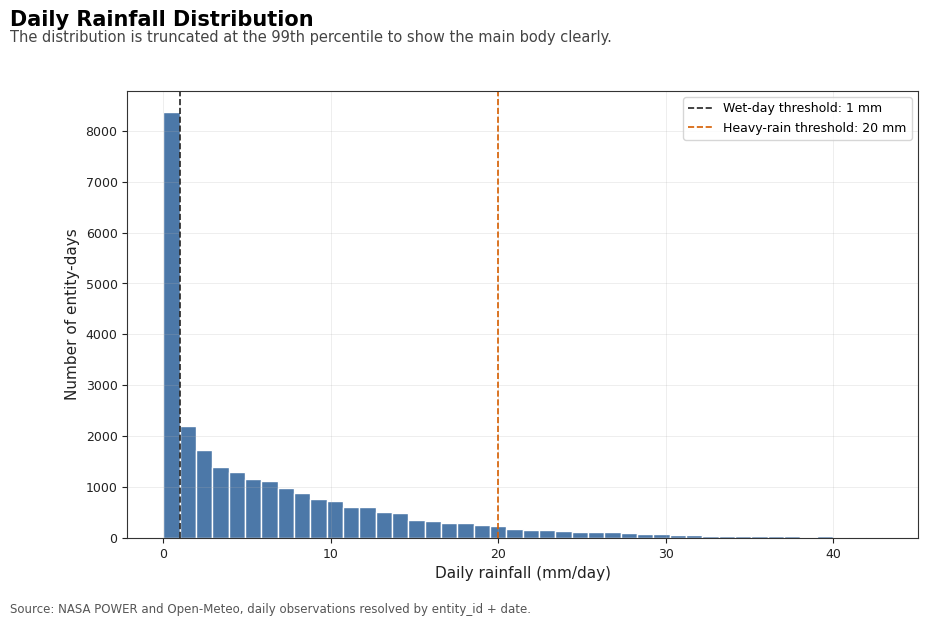

C:\Users\Hello\AppData\Local\Temp\ipykernel_7960\2358294040.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=box_order, showfliers=False, patch_artist=True, boxprops={'facecolor': '#A6CEE3', 'color': '#1F78B4'}, medianprops={'color': '#B2182B', 'linewidth': 1.7})


Saved figure: reports\02_EDA_report\figures\05_city_rainfall_boxplots.png


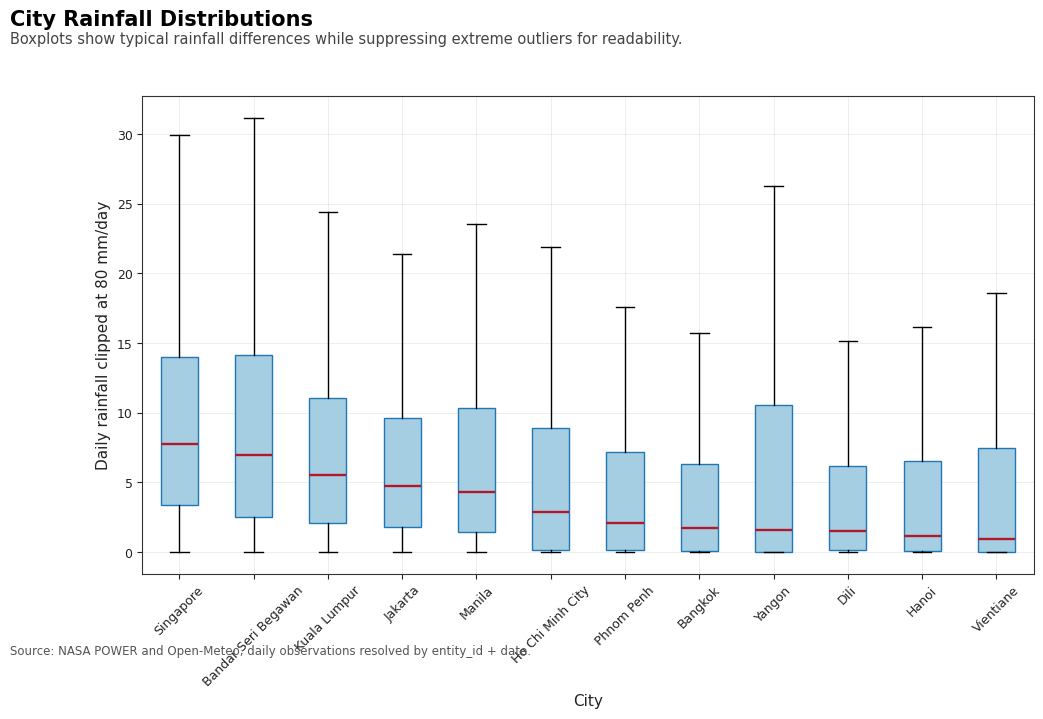

In [7]:
fig, ax = plt.subplots(figsize=(10.2, 5.8))
bins = np.linspace(0, np.nanpercentile(eda_df['rainfall_mm'], 99), 45)
ax.hist(eda_df['rainfall_mm'], bins=bins, color='#4C78A8', edgecolor='white')
ax.axvline(1, color='#222222', linestyle='--', linewidth=1.2, label='Wet-day threshold: 1 mm')
ax.axvline(20, color='#D55E00', linestyle='--', linewidth=1.2, label='Heavy-rain threshold: 20 mm')
ax.set_xlabel('Daily rainfall (mm/day)')
ax.set_ylabel('Number of entity-days')
ax.legend()
add_title(fig, 'Daily Rainfall Distribution', 'The distribution is truncated at the 99th percentile to show the main body clearly.')
add_source_note(fig)
save_figure(fig, '04_daily_rainfall_distribution.png')
plt.show()

box_order = city_summary.sort_values('median_daily_precip_mm', ascending=False)['location_name']
box_data = [eda_df.loc[eda_df['location_name'] == city, 'rainfall_mm'].clip(upper=80) for city in box_order]
fig, ax = plt.subplots(figsize=(11.5, 6.2))
ax.boxplot(box_data, labels=box_order, showfliers=False, patch_artist=True, boxprops={'facecolor': '#A6CEE3', 'color': '#1F78B4'}, medianprops={'color': '#B2182B', 'linewidth': 1.7})
ax.set_ylabel('Daily rainfall clipped at 80 mm/day')
ax.set_xlabel('City')
ax.tick_params(axis='x', rotation=45)
add_title(fig, 'City Rainfall Distributions', 'Boxplots show typical rainfall differences while suppressing extreme outliers for readability.')
add_source_note(fig)
save_figure(fig, '05_city_rainfall_boxplots.png')
plt.show()


## 6. Monthly and Seasonal Structure

The dataset is daily, but rainfall risk is seasonal. Monthly aggregation exposes monsoon-like cycles and helps detect whether source disagreement is concentrated in wet months.

Saved table: reports\02_EDA_report\tables\06_monthly_city_rainfall.csv
Saved table: reports\02_EDA_report\tables\07_monthly_city_climatology.csv
Saved figure: reports\02_EDA_report\figures\06_monthly_rainfall_climatology_heatmap.png


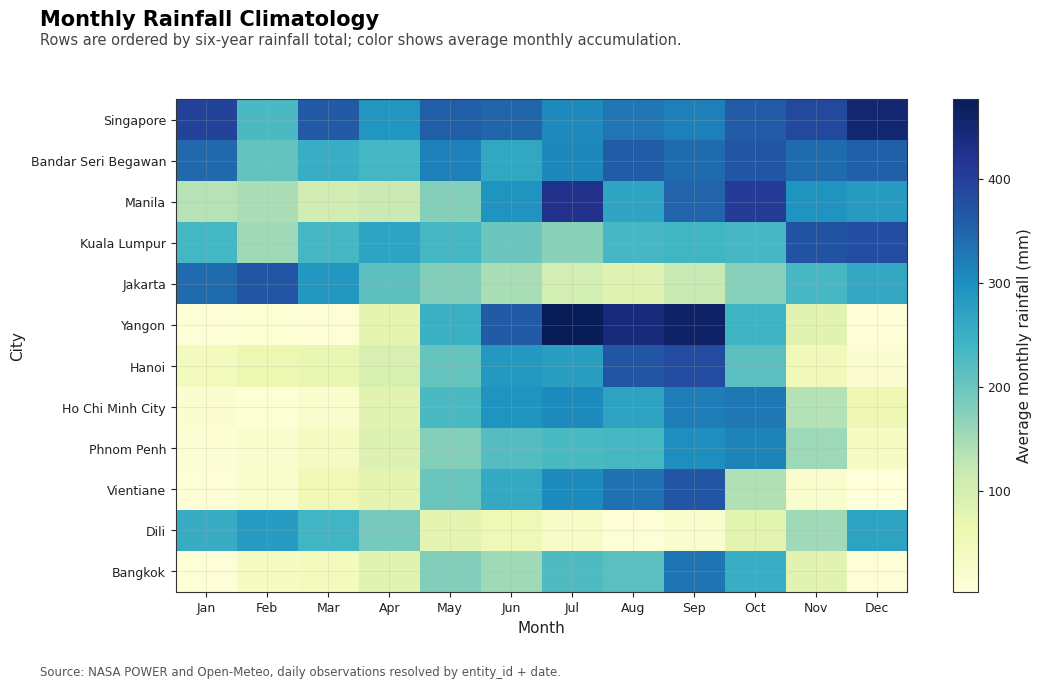

Saved figure: reports\02_EDA_report\figures\07_monthly_rainfall_seasonality_lines.png


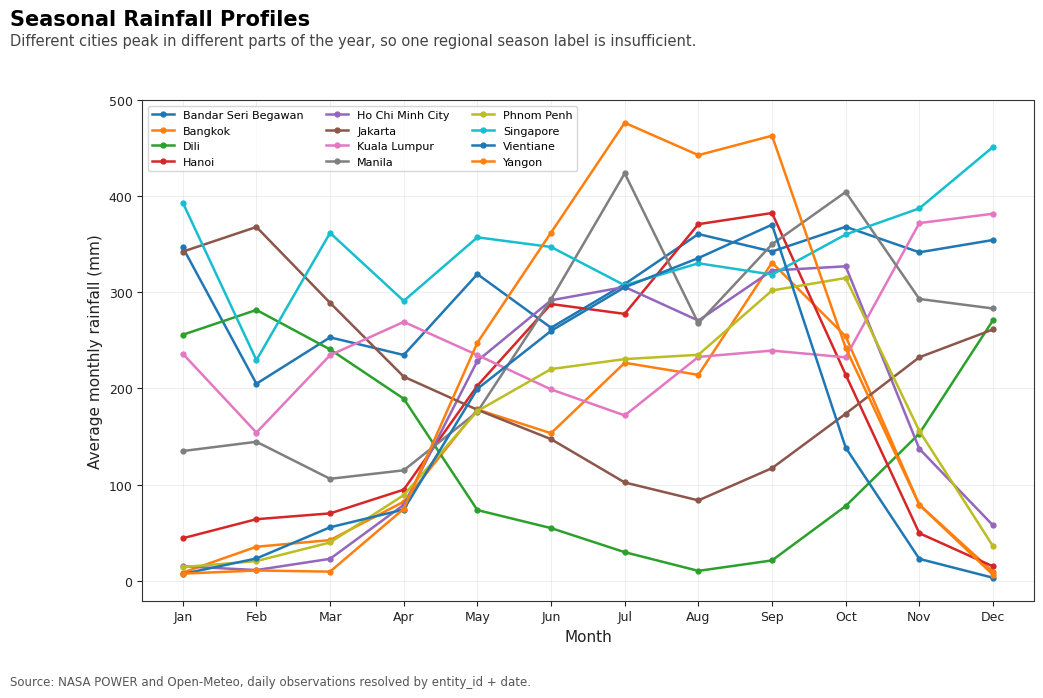

Saved figure: reports\02_EDA_report\figures\08_monthly_rainy_day_frequency_heatmap.png


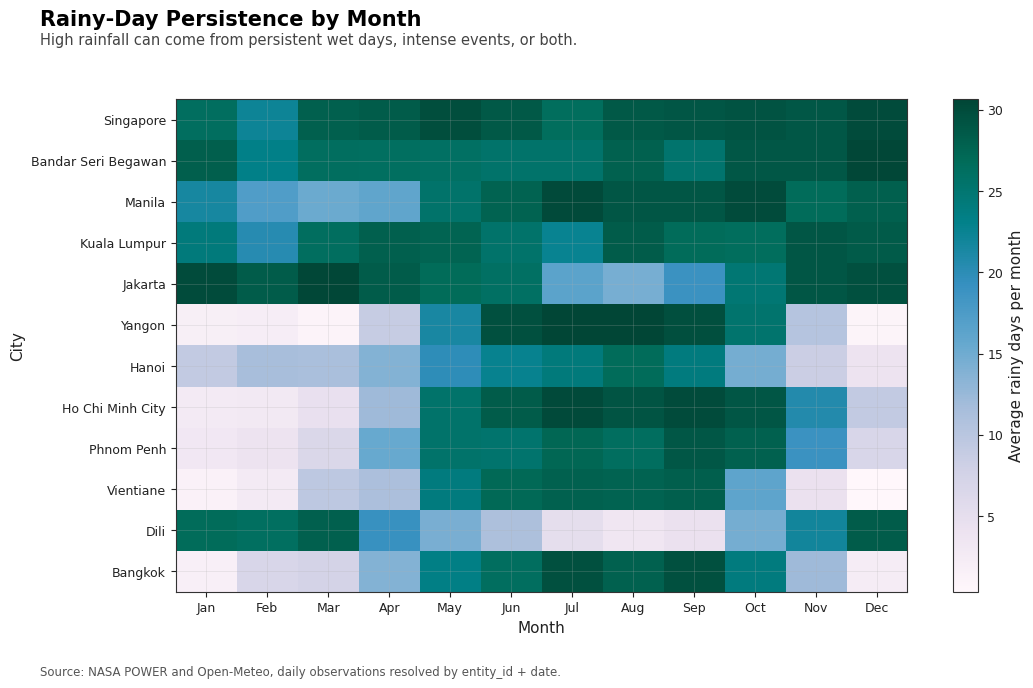

In [8]:
monthly_city = (
    eda_df.groupby(['entity_id', 'country', 'location_name', 'year_month', 'year', 'month'], as_index=False)
    .agg(
        monthly_precip_mm=('rainfall_mm', 'sum'),
        monthly_nasa_precip_mm=('nasa_power_precipitation_mm', 'sum'),
        monthly_open_meteo_precip_mm=('open_meteo_precipitation_mm', 'sum'),
        mean_daily_source_abs_diff_mm=('source_abs_diff_mm', 'mean'),
        rainy_days=('wet_day', 'sum'),
        heavy_rain_days=('heavy_rain_day', 'sum'),
    )
)
monthly_city['monthly_source_bias_mm'] = monthly_city['monthly_nasa_precip_mm'] - monthly_city['monthly_open_meteo_precip_mm']

monthly_climatology = (
    monthly_city.groupby(['entity_id', 'country', 'location_name', 'month'], as_index=False)
    .agg(
        avg_monthly_precip_mm=('monthly_precip_mm', 'mean'),
        avg_monthly_nasa_precip_mm=('monthly_nasa_precip_mm', 'mean'),
        avg_monthly_open_meteo_precip_mm=('monthly_open_meteo_precip_mm', 'mean'),
        avg_daily_source_abs_diff_mm=('mean_daily_source_abs_diff_mm', 'mean'),
        avg_monthly_source_bias_mm=('monthly_source_bias_mm', 'mean'),
        avg_rainy_days=('rainy_days', 'mean'),
        avg_heavy_rain_days=('heavy_rain_days', 'mean'),
    )
)
monthly_climatology['month_name'] = monthly_climatology['month'].map(lambda month: MONTH_LABELS[month - 1])

save_table(monthly_city, '06_monthly_city_rainfall.csv')
save_table(monthly_climatology, '07_monthly_city_climatology.csv')

rain_pivot = monthly_climatology.pivot(index='location_name', columns='month', values='avg_monthly_precip_mm')
rain_pivot = rain_pivot.loc[city_summary['location_name']]

fig, ax = plt.subplots(figsize=(11.8, 6.4))
image = ax.imshow(rain_pivot.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(np.arange(12))
ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(np.arange(len(rain_pivot.index)))
ax.set_yticklabels(rain_pivot.index)
ax.set_xlabel('Month')
ax.set_ylabel('City')
cbar = fig.colorbar(image, ax=ax)
cbar.set_label('Average monthly rainfall (mm)')
add_title(fig, 'Monthly Rainfall Climatology', 'Rows are ordered by six-year rainfall total; color shows average monthly accumulation.')
add_source_note(fig)
save_figure(fig, '06_monthly_rainfall_climatology_heatmap.png')
plt.show()

fig, ax = plt.subplots(figsize=(11.5, 6.5))
for location_name, group in monthly_climatology.groupby('location_name'):
    group = group.sort_values('month')
    ax.plot(group['month'], group['avg_monthly_precip_mm'], linewidth=1.8, marker='o', markersize=3.5, label=location_name)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_xlabel('Month')
ax.set_ylabel('Average monthly rainfall (mm)')
ax.legend(ncol=3, fontsize=8, frameon=True)
add_title(fig, 'Seasonal Rainfall Profiles', 'Different cities peak in different parts of the year, so one regional season label is insufficient.')
add_source_note(fig)
save_figure(fig, '07_monthly_rainfall_seasonality_lines.png')
plt.show()

wet_pivot = monthly_climatology.pivot(index='location_name', columns='month', values='avg_rainy_days').loc[city_summary['location_name']]
fig, ax = plt.subplots(figsize=(11.8, 6.4))
image = ax.imshow(wet_pivot.values, aspect='auto', cmap='PuBuGn')
ax.set_xticks(np.arange(12))
ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(np.arange(len(wet_pivot.index)))
ax.set_yticklabels(wet_pivot.index)
ax.set_xlabel('Month')
ax.set_ylabel('City')
cbar = fig.colorbar(image, ax=ax)
cbar.set_label('Average rainy days per month')
add_title(fig, 'Rainy-Day Persistence by Month', 'High rainfall can come from persistent wet days, intense events, or both.')
add_source_note(fig)
save_figure(fig, '08_monthly_rainy_day_frequency_heatmap.png')
plt.show()


## 7. Interannual Variation and Rolling Rainfall Context

The following charts ask whether high-rainfall cities are consistently wet every year or dominated by a few anomalous periods.

Saved table: reports\02_EDA_report\tables\08_annual_city_rainfall.csv
Saved figure: reports\02_EDA_report\figures\09_annual_rainfall_heatmap.png


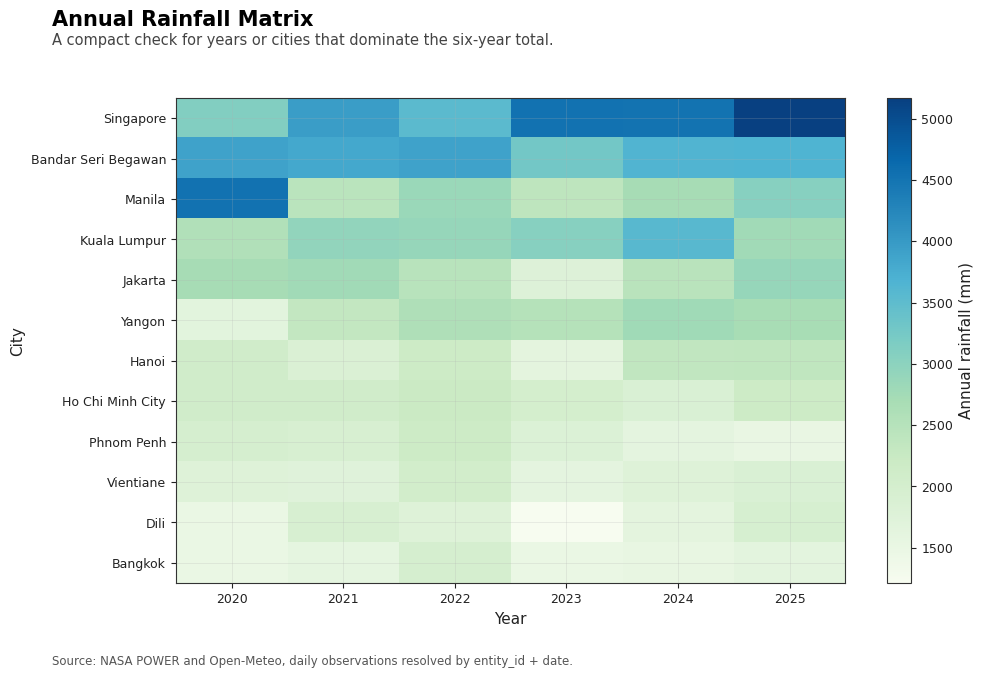

Saved figure: reports\02_EDA_report\figures\10_rolling_30d_rainfall_top_cities.png


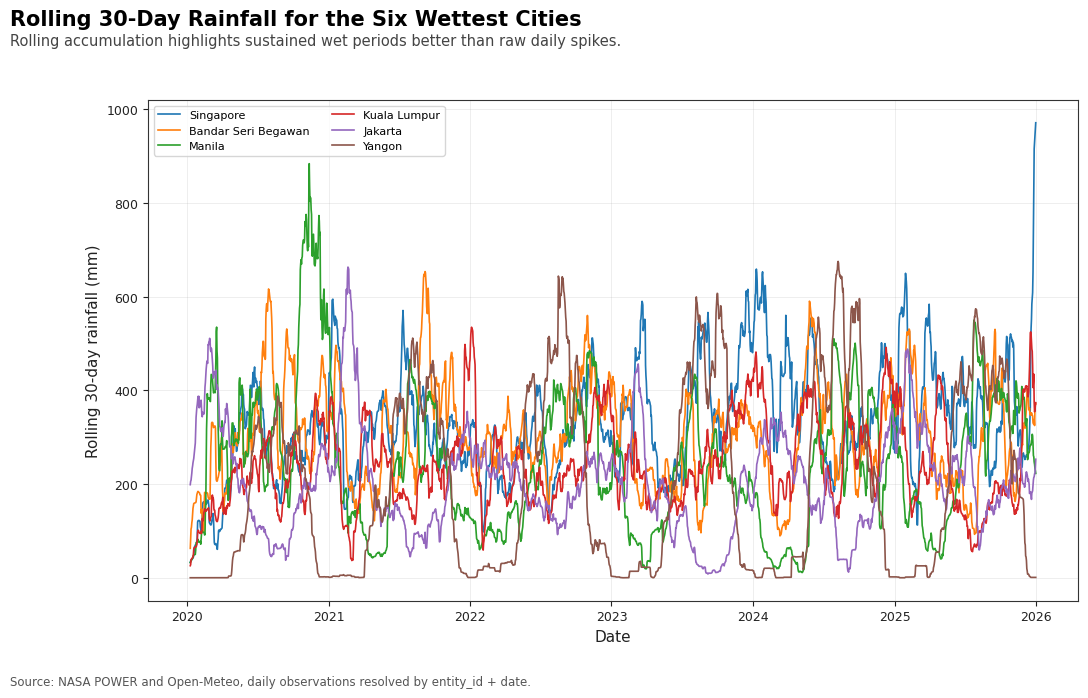

In [9]:
annual_city = (
    eda_df.groupby(['entity_id', 'country', 'location_name', 'year'], as_index=False)
    .agg(
        annual_rainfall_mm=('rainfall_mm', 'sum'),
        wet_days=('wet_day', 'sum'),
        heavy_rain_days=('heavy_rain_day', 'sum'),
        mean_source_abs_diff_mm=('source_abs_diff_mm', 'mean'),
    )
)
save_table(annual_city, '08_annual_city_rainfall.csv')

annual_pivot = annual_city.pivot(index='location_name', columns='year', values='annual_rainfall_mm').loc[city_summary['location_name']]
fig, ax = plt.subplots(figsize=(10.8, 6.3))
image = ax.imshow(annual_pivot.values, aspect='auto', cmap='GnBu')
ax.set_xticks(np.arange(len(annual_pivot.columns)))
ax.set_xticklabels(annual_pivot.columns)
ax.set_yticks(np.arange(len(annual_pivot.index)))
ax.set_yticklabels(annual_pivot.index)
ax.set_xlabel('Year')
ax.set_ylabel('City')
cbar = fig.colorbar(image, ax=ax)
cbar.set_label('Annual rainfall (mm)')
add_title(fig, 'Annual Rainfall Matrix', 'A compact check for years or cities that dominate the six-year total.')
add_source_note(fig)
save_figure(fig, '09_annual_rainfall_heatmap.png')
plt.show()

top_cities = city_summary.head(6)['location_name'].tolist()
fig, ax = plt.subplots(figsize=(12, 6.5))
for city in top_cities:
    group = eda_df[eda_df['location_name'] == city].sort_values('date')
    ax.plot(group['date'], group['rainfall_rolling_30d_sum'], linewidth=1.2, label=city)
ax.set_xlabel('Date')
ax.set_ylabel('Rolling 30-day rainfall (mm)')
ax.legend(ncol=2, fontsize=8, frameon=True)
add_title(fig, 'Rolling 30-Day Rainfall for the Six Wettest Cities', 'Rolling accumulation highlights sustained wet periods better than raw daily spikes.')
add_source_note(fig)
save_figure(fig, '10_rolling_30d_rainfall_top_cities.png')
plt.show()


## 8. Source Agreement: Can the Two APIs Be Treated as Interchangeable?

The two sources describe the same entity-date, but they are not identical sensors. Their differences estimate measurement/model uncertainty and should be documented before target construction.

Saved table: reports\02_EDA_report\tables\09_source_agreement_by_city.csv


,entity_id,country,location_name,nasa_mean_daily_precip_mm,open_meteo_mean_daily_precip_mm,mean_abs_diff_mm,median_abs_diff_mm,p95_abs_diff_mm,mean_bias_nasa_minus_open_meteo_mm
7,SEA_SG_SINGAPORE,Singapore,Singapore,13.266724,9.371670,10.455164,4.540,43.2625,3.895055
0,SEA_BN_BANDAR_SERI_BEGAWAN,Brunei,Bandar Seri Begawan,10.033285,10.210265,7.841250,4.180,26.6625,-0.176980
6,SEA_PH_MANILA,Philippines,Manila,10.095005,6.279151,7.132605,3.025,24.7215,3.815853
5,SEA_MY_KUALA_LUMPUR,Malaysia,Kuala Lumpur,7.931300,8.262865,6.863271,4.140,23.1950,-0.331565
4,SEA_MM_YANGON,Myanmar,Yangon,5.709681,7.544891,5.875347,1.025,25.0835,-1.835210
1,SEA_ID_JAKARTA,Indonesia,Jakarta,6.814927,6.908668,5.425246,2.810,19.8190,-0.093741
9,SEA_TL_DILI,Timor-Leste,Dili,3.324183,5.751597,5.195871,1.790,21.2125,-2.427413
2,SEA_KH_PHNOM_PENH,Cambodia,Phnom Penh,4.540192,5.498723,5.015301,1.550,20.3350,-0.958531
11,SEA_VN_HO_CHI_MINH,Vietnam,Ho Chi Minh City,4.789909,6.534626,4.910593,1.880,18.4350,-1.744717
10,SEA_VN_HANOI,Vietnam,Hanoi,5.251651,6.096898,4.749845,0.990,21.6540,-0.845246


Saved figure: reports\02_EDA_report\figures\11_source_agreement_hexbin.png


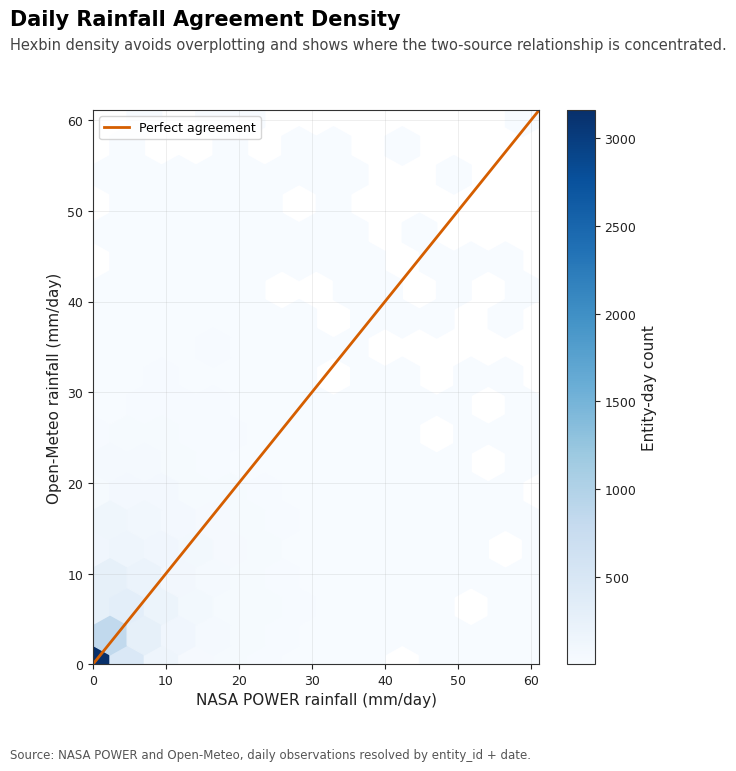

Saved figure: reports\02_EDA_report\figures\12_source_agreement_bland_altman.png


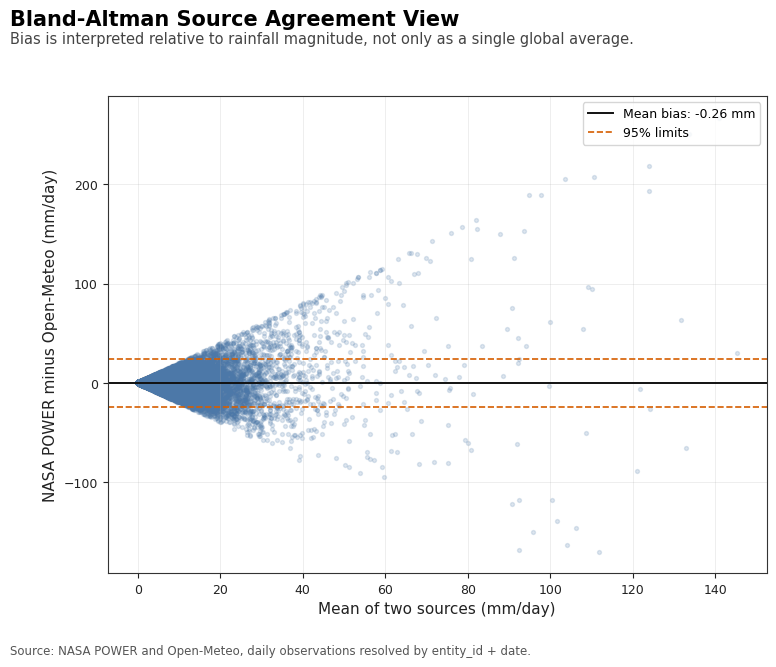

Saved figure: reports\02_EDA_report\figures\13_source_disagreement_by_city.png


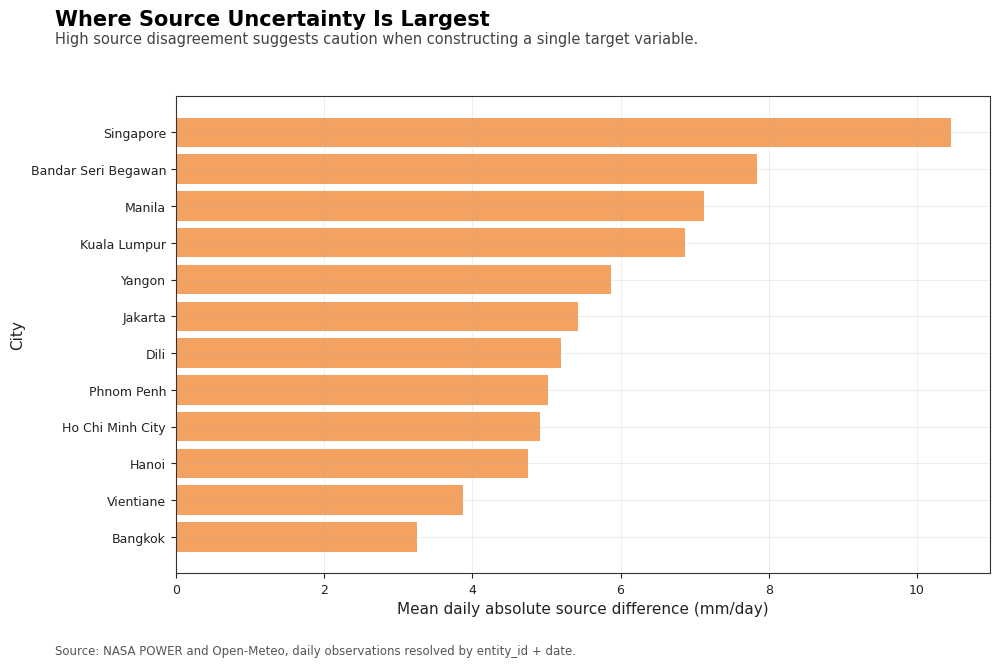

In [10]:
source_agreement_by_city = (
    eda_df.groupby(['entity_id', 'country', 'location_name'], as_index=False)
    .agg(
        nasa_mean_daily_precip_mm=('nasa_power_precipitation_mm', 'mean'),
        open_meteo_mean_daily_precip_mm=('open_meteo_precipitation_mm', 'mean'),
        mean_abs_diff_mm=('source_abs_diff_mm', 'mean'),
        median_abs_diff_mm=('source_abs_diff_mm', 'median'),
        p95_abs_diff_mm=('source_abs_diff_mm', lambda s: s.quantile(0.95)),
        mean_bias_nasa_minus_open_meteo_mm=('source_bias_mm', 'mean'),
    )
    .sort_values('mean_abs_diff_mm', ascending=False)
)
save_table(source_agreement_by_city, '09_source_agreement_by_city.csv')
display(source_agreement_by_city)

sample_for_scatter = eda_df.sample(min(len(eda_df), 9000), random_state=108)
fig, ax = plt.subplots(figsize=(7.2, 7.2))
hb = ax.hexbin(
    sample_for_scatter['nasa_power_precipitation_mm'],
    sample_for_scatter['open_meteo_precipitation_mm'],
    gridsize=55,
    cmap='Blues',
    mincnt=1,
)
max_value = float(np.nanpercentile(eda_df[['nasa_power_precipitation_mm', 'open_meteo_precipitation_mm']].values, 99.4))
ax.plot([0, max_value], [0, max_value], color='#D55E00', linewidth=2, label='Perfect agreement')
ax.set_xlim(0, max_value)
ax.set_ylim(0, max_value)
ax.set_xlabel('NASA POWER rainfall (mm/day)')
ax.set_ylabel('Open-Meteo rainfall (mm/day)')
ax.legend(loc='upper left')
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Entity-day count')
add_title(fig, 'Daily Rainfall Agreement Density', 'Hexbin density avoids overplotting and shows where the two-source relationship is concentrated.')
add_source_note(fig)
save_figure(fig, '11_source_agreement_hexbin.png')
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6.2))
daily_mean_sources = eda_df[['nasa_power_precipitation_mm', 'open_meteo_precipitation_mm']].mean(axis=1)
daily_diff_sources = eda_df['source_bias_mm']
ax.scatter(daily_mean_sources, daily_diff_sources, s=8, alpha=0.18, color='#4C78A8')
mean_bias = daily_diff_sources.mean()
loa = 1.96 * daily_diff_sources.std()
ax.axhline(mean_bias, color='#111111', linewidth=1.4, label=f'Mean bias: {mean_bias:.2f} mm')
ax.axhline(mean_bias + loa, color='#D55E00', linestyle='--', linewidth=1.2, label='95% limits')
ax.axhline(mean_bias - loa, color='#D55E00', linestyle='--', linewidth=1.2)
ax.set_xlabel('Mean of two sources (mm/day)')
ax.set_ylabel('NASA POWER minus Open-Meteo (mm/day)')
ax.legend(loc='upper right')
add_title(fig, 'Bland-Altman Source Agreement View', 'Bias is interpreted relative to rainfall magnitude, not only as a single global average.')
add_source_note(fig)
save_figure(fig, '12_source_agreement_bland_altman.png')
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 6.2))
ordered = source_agreement_by_city.sort_values('mean_abs_diff_mm', ascending=True)
ax.barh(ordered['location_name'], ordered['mean_abs_diff_mm'], color='#F4A261')
ax.set_xlabel('Mean daily absolute source difference (mm/day)')
ax.set_ylabel('City')
add_title(fig, 'Where Source Uncertainty Is Largest', 'High source disagreement suggests caution when constructing a single target variable.')
add_source_note(fig)
save_figure(fig, '13_source_disagreement_by_city.png')
plt.show()


## 9. Source Differences Across Months

A global source difference is not enough. If disagreement is seasonal, then imputation, validation, and target construction should be season-aware.

Saved figure: reports\02_EDA_report\figures\14_monthly_source_abs_difference_heatmap.png


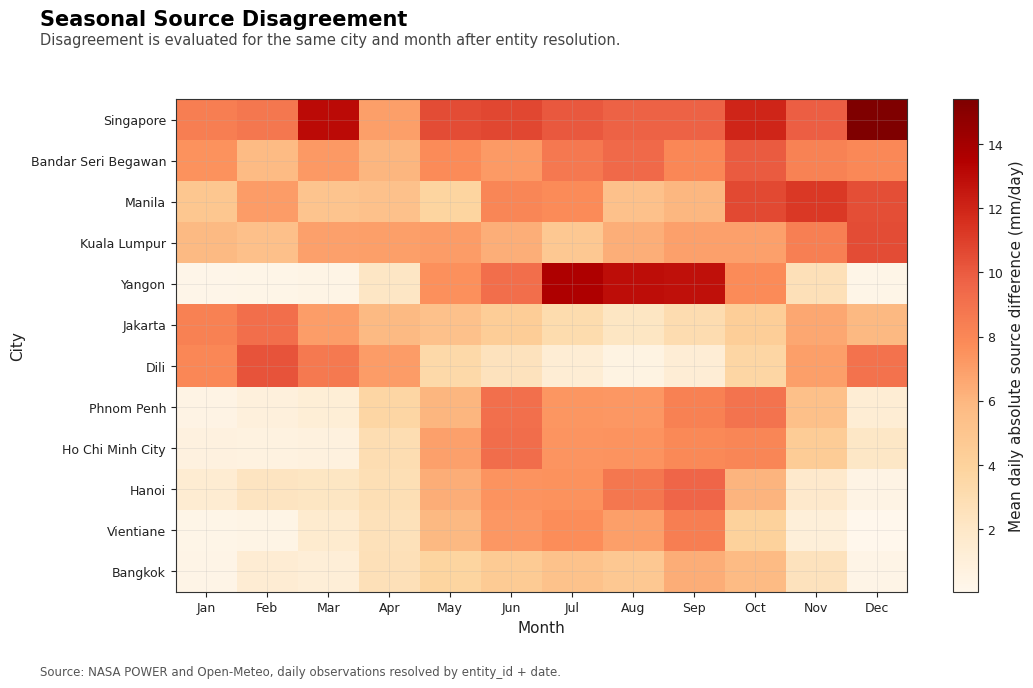

Saved figure: reports\02_EDA_report\figures\15_monthly_source_bias_heatmap.png


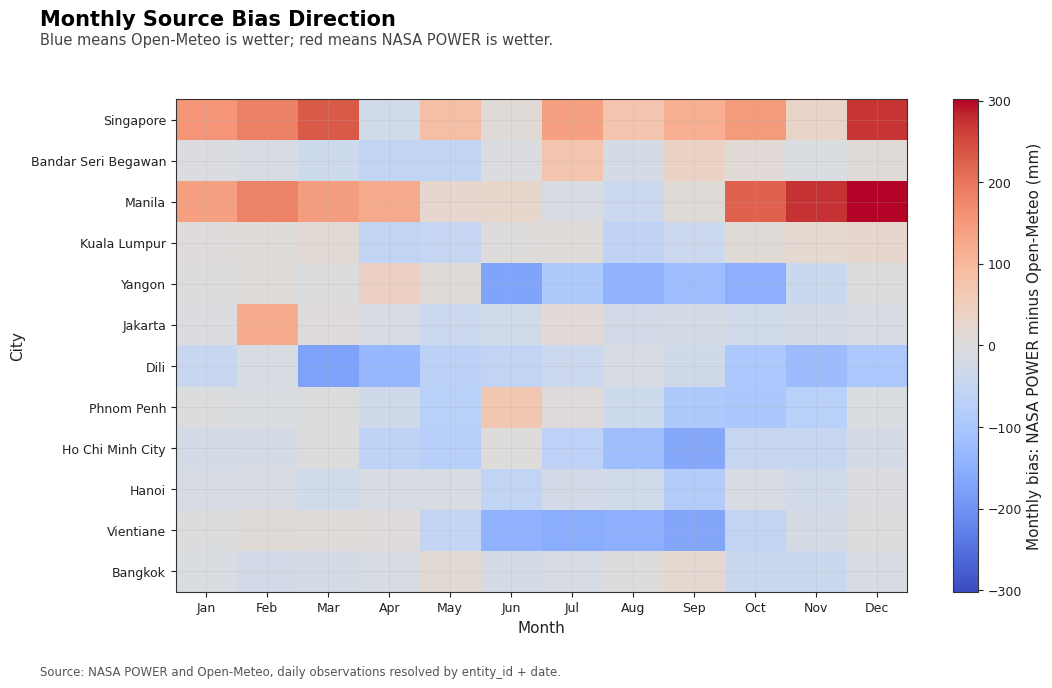

In [11]:
diff_pivot = monthly_climatology.pivot(index='location_name', columns='month', values='avg_daily_source_abs_diff_mm').loc[source_agreement_by_city['location_name']]
fig, ax = plt.subplots(figsize=(11.8, 6.4))
image = ax.imshow(diff_pivot.values, aspect='auto', cmap='OrRd')
ax.set_xticks(np.arange(12))
ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(np.arange(len(diff_pivot.index)))
ax.set_yticklabels(diff_pivot.index)
ax.set_xlabel('Month')
ax.set_ylabel('City')
cbar = fig.colorbar(image, ax=ax)
cbar.set_label('Mean daily absolute source difference (mm/day)')
add_title(fig, 'Seasonal Source Disagreement', 'Disagreement is evaluated for the same city and month after entity resolution.')
add_source_note(fig)
save_figure(fig, '14_monthly_source_abs_difference_heatmap.png')
plt.show()

bias_pivot = monthly_climatology.pivot(index='location_name', columns='month', values='avg_monthly_source_bias_mm').loc[source_agreement_by_city['location_name']]
bias_limit = np.nanmax(np.abs(bias_pivot.values))
fig, ax = plt.subplots(figsize=(11.8, 6.4))
image = ax.imshow(bias_pivot.values, aspect='auto', cmap='coolwarm', vmin=-bias_limit, vmax=bias_limit)
ax.set_xticks(np.arange(12))
ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(np.arange(len(bias_pivot.index)))
ax.set_yticklabels(bias_pivot.index)
ax.set_xlabel('Month')
ax.set_ylabel('City')
cbar = fig.colorbar(image, ax=ax)
cbar.set_label('Monthly bias: NASA POWER minus Open-Meteo (mm)')
add_title(fig, 'Monthly Source Bias Direction', 'Blue means Open-Meteo is wetter; red means NASA POWER is wetter.')
add_source_note(fig)
save_figure(fig, '15_monthly_source_bias_heatmap.png')
plt.show()


## 10. Feature Relationships After Engineering

This view checks whether engineered temporal and uncertainty features carry distinct information or simply duplicate rainfall magnitude.

Saved table: reports\02_EDA_report\tables\10_engineered_feature_correlation_matrix.csv
Saved figure: reports\02_EDA_report\figures\16_engineered_feature_correlation_heatmap.png


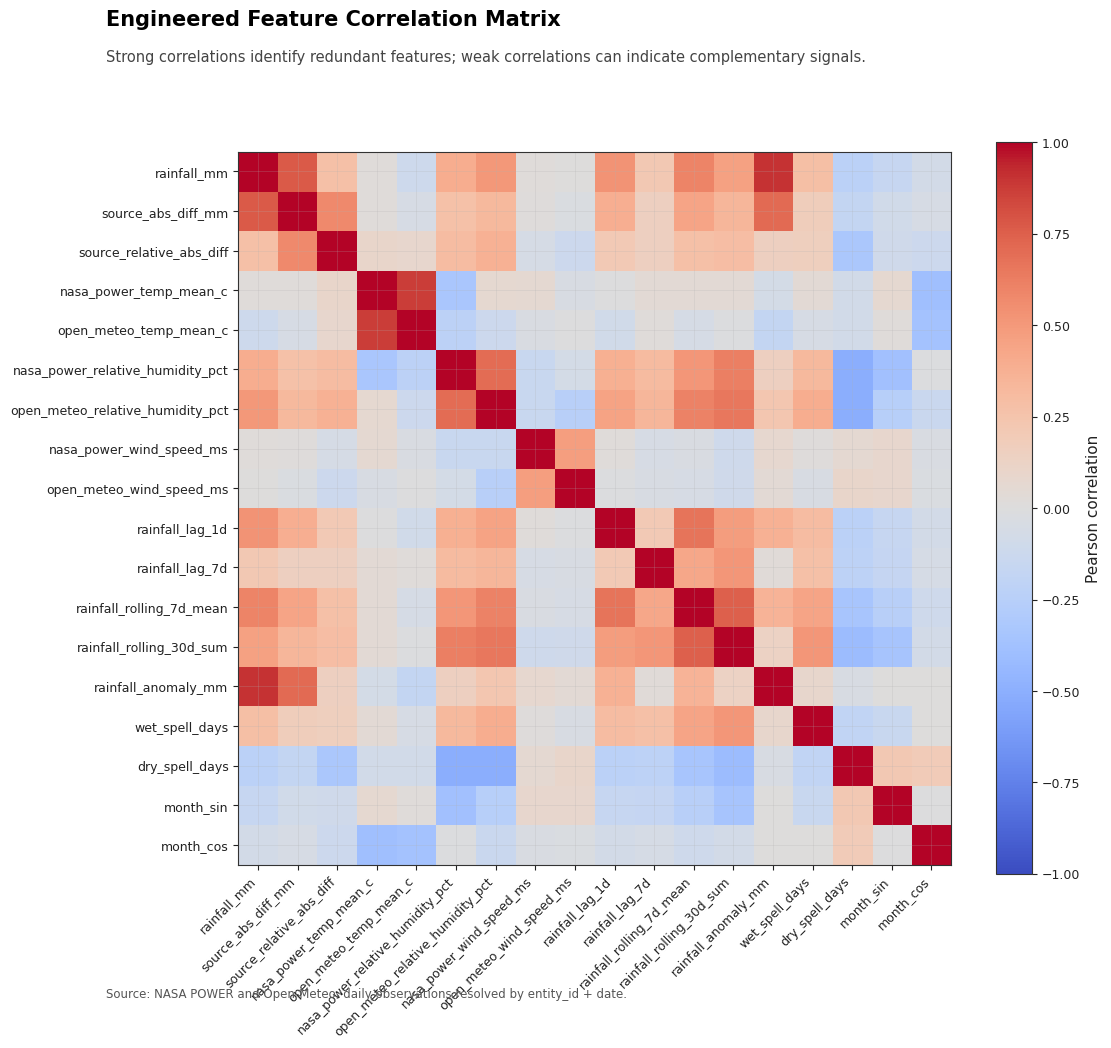

In [12]:
correlation_cols = [
    'rainfall_mm', 'source_abs_diff_mm', 'source_relative_abs_diff', 'nasa_power_temp_mean_c',
    'open_meteo_temp_mean_c', 'nasa_power_relative_humidity_pct', 'open_meteo_relative_humidity_pct',
    'nasa_power_wind_speed_ms', 'open_meteo_wind_speed_ms', 'rainfall_lag_1d', 'rainfall_lag_7d',
    'rainfall_rolling_7d_mean', 'rainfall_rolling_30d_sum', 'rainfall_anomaly_mm',
    'wet_spell_days', 'dry_spell_days', 'month_sin', 'month_cos'
]
corr = eda_df[correlation_cols].corr(numeric_only=True)
save_table(corr.reset_index().rename(columns={'index': 'feature'}), '10_engineered_feature_correlation_matrix.csv')

fig, ax = plt.subplots(figsize=(11.5, 9.5))
image = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(corr.index)))
ax.set_yticklabels(corr.index)
cbar = fig.colorbar(image, ax=ax)
cbar.set_label('Pearson correlation')
add_title(fig, 'Engineered Feature Correlation Matrix', 'Strong correlations identify redundant features; weak correlations can indicate complementary signals.')
add_source_note(fig)
save_figure(fig, '16_engineered_feature_correlation_heatmap.png')
plt.show()


## 11. Publication-Ready Regional Maps

The maps use Cartopy Natural Earth land, ocean, coastline, and country-border layers. Markers are analytical entities; the basemap provides geographical context rather than a dot-only coordinate plot.

Saved table: reports\02_EDA_report\tables\11_regional_map_city_statistics.csv
Saved figure: reports\02_EDA_report\figures\17_map_mean_daily_rainfall_with_basemap.png


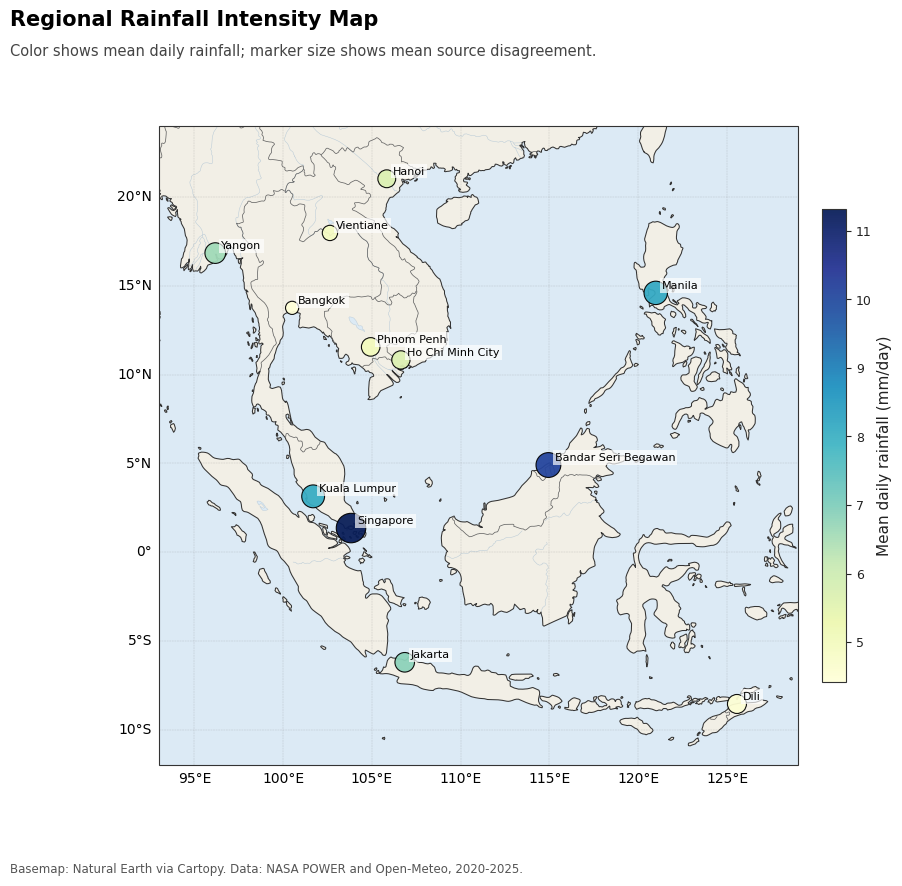

Saved figure: reports\02_EDA_report\figures\18_map_wet_day_ratio_with_basemap.png


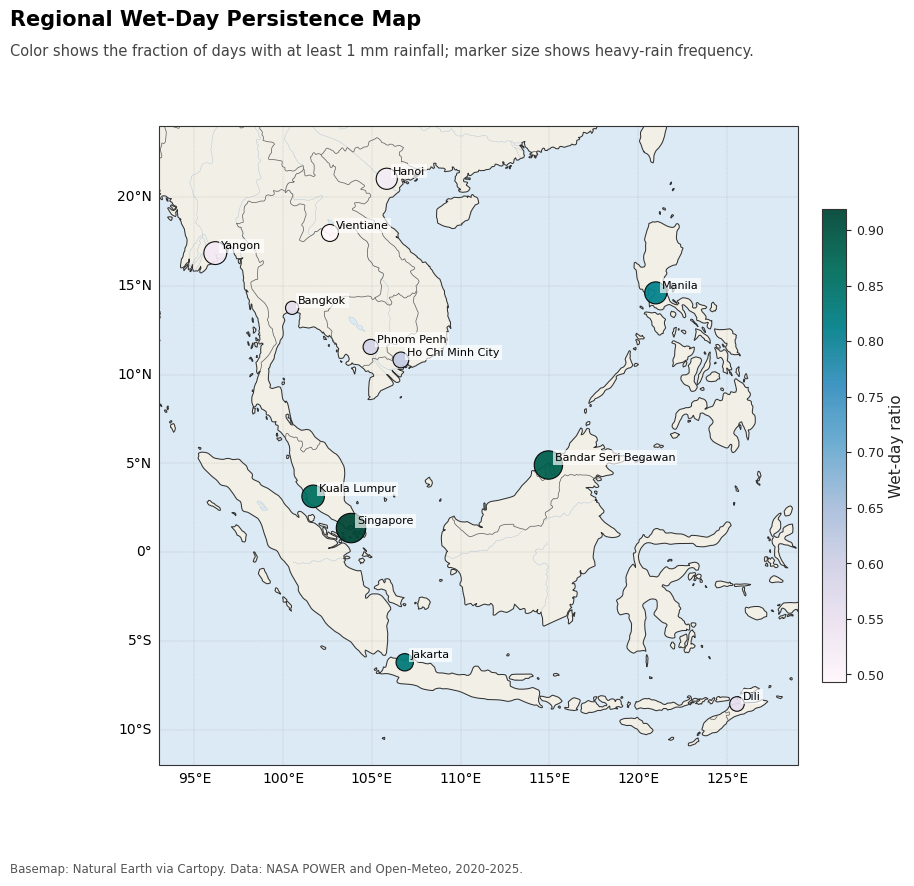

Saved figure: reports\02_EDA_report\figures\19_map_source_disagreement_with_basemap.png


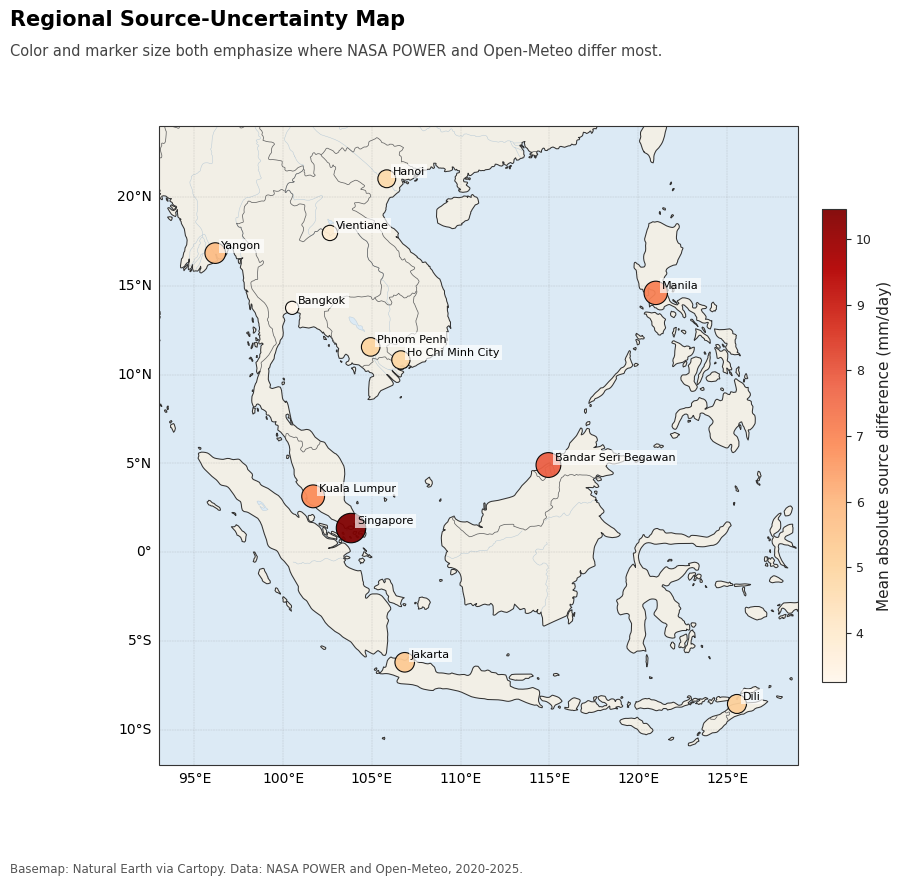

In [13]:
map_stats = registry_df.merge(
    city_summary[[
        'entity_id', 'mean_daily_precip_mm', 'total_precip_2020_2025_mm', 'wet_day_ratio',
        'heavy_rain_day_ratio', 'longest_wet_spell_days', 'longest_dry_spell_days', 'mean_source_abs_diff_mm'
    ]],
    on='entity_id',
    how='left',
)
save_table(map_stats, '11_regional_map_city_statistics.csv')

def add_sea_basemap(ax):
    ax.set_extent([93, 129, -12, 24], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#DCEAF5', zorder=0)
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#F2EFE6', zorder=0)
    ax.add_feature(cfeature.LAKES.with_scale('50m'), facecolor='#DCEAF5', edgecolor='#B7C9D6', linewidth=0.3, zorder=1)
    ax.add_feature(cfeature.RIVERS.with_scale('50m'), edgecolor='#B7C9D6', linewidth=0.35, zorder=1)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, edgecolor='#333333', zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.55, edgecolor='#666666', zorder=2)
    gridlines = ax.gridlines(draw_labels=True, linewidth=0.35, color='#777777', alpha=0.35, linestyle='--')
    gridlines.top_labels = False
    gridlines.right_labels = False


def plot_cartopy_metric(metric_col, title, subtitle, colorbar_label, filename, cmap='viridis', size_col=None):
    if not CARTOPY_AVAILABLE:
        print('Cartopy is not available; skipping map:', filename)
        return
    fig = plt.figure(figsize=(10.5, 8.3))
    ax = plt.axes(projection=ccrs.PlateCarree())
    add_sea_basemap(ax)
    if size_col is None:
        sizes = np.full(len(map_stats), 150)
    else:
        values = map_stats[size_col].fillna(0)
        sizes = 90 + (values - values.min()) / (values.max() - values.min() + 1e-9) * 360
    scatter = ax.scatter(
        map_stats['canonical_longitude'],
        map_stats['canonical_latitude'],
        c=map_stats[metric_col],
        s=sizes,
        cmap=cmap,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.94,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )
    for _, row in map_stats.iterrows():
        ax.text(
            row['canonical_longitude'] + 0.35,
            row['canonical_latitude'] + 0.25,
            row['location_name'],
            fontsize=8,
            transform=ccrs.PlateCarree(),
            zorder=6,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.68, 'pad': 1.5},
        )
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.74, pad=0.03)
    cbar.set_label(colorbar_label)
    add_title(fig, title, subtitle)
    add_source_note(fig, 'Basemap: Natural Earth via Cartopy. Data: NASA POWER and Open-Meteo, 2020-2025.')
    save_figure(fig, filename)
    plt.show()

plot_cartopy_metric(
    'mean_daily_precip_mm',
    'Regional Rainfall Intensity Map',
    'Color shows mean daily rainfall; marker size shows mean source disagreement.',
    'Mean daily rainfall (mm/day)',
    '17_map_mean_daily_rainfall_with_basemap.png',
    cmap='YlGnBu',
    size_col='mean_source_abs_diff_mm',
)
plot_cartopy_metric(
    'wet_day_ratio',
    'Regional Wet-Day Persistence Map',
    'Color shows the fraction of days with at least 1 mm rainfall; marker size shows heavy-rain frequency.',
    'Wet-day ratio',
    '18_map_wet_day_ratio_with_basemap.png',
    cmap='PuBuGn',
    size_col='heavy_rain_day_ratio',
)
plot_cartopy_metric(
    'mean_source_abs_diff_mm',
    'Regional Source-Uncertainty Map',
    'Color and marker size both emphasize where NASA POWER and Open-Meteo differ most.',
    'Mean absolute source difference (mm/day)',
    '19_map_source_disagreement_with_basemap.png',
    cmap='OrRd',
    size_col='mean_source_abs_diff_mm',
)


## 12. Data Storytelling Summary

This cell converts the EDA tables into concise, evidence-backed claims. These claims are useful for the written report because they connect raw data inspection to methodological decisions.

In [14]:
wettest_city = city_summary.iloc[0]
most_persistent_city = city_summary.sort_values('wet_day_ratio', ascending=False).iloc[0]
largest_gap_city = source_agreement_by_city.iloc[0]
driest_city = city_summary.sort_values('total_precip_2020_2025_mm', ascending=True).iloc[0]

peak_months = (
    monthly_climatology.sort_values('avg_monthly_precip_mm', ascending=False)
    .groupby('location_name')
    .head(1)
    .sort_values('location_name')
    [['location_name', 'month_name', 'avg_monthly_precip_mm']]
)

findings = pd.DataFrame([
    {'finding_type': 'rainfall_burden', 'finding': f"{wettest_city['location_name']} has the highest six-year rainfall total ({wettest_city['total_precip_2020_2025_mm']:.0f} mm)."},
    {'finding_type': 'rainfall_persistence', 'finding': f"{most_persistent_city['location_name']} has the highest wet-day ratio ({most_persistent_city['wet_day_ratio']:.1%})."},
    {'finding_type': 'dry_reference', 'finding': f"{driest_city['location_name']} has the lowest six-year rainfall total ({driest_city['total_precip_2020_2025_mm']:.0f} mm)."},
    {'finding_type': 'source_uncertainty', 'finding': f"{largest_gap_city['location_name']} has the largest mean daily NASA/Open-Meteo absolute difference ({largest_gap_city['mean_abs_diff_mm']:.2f} mm/day)."},
    {'finding_type': 'methodological_implication', 'finding': 'The resolved dataset should retain source-specific rainfall columns and source-gap features; collapsing to one target without auditing disagreement can hide uncertainty.'},
    {'finding_type': 'feature_engineering_implication', 'finding': 'Lag, rolling, anomaly, spell-length, and cyclic month features are justified because rainfall varies by persistence, intensity, city, and season.'},
])
save_table(findings, '12_storytelling_findings.csv')
save_table(peak_months, '13_peak_rainfall_month_by_city.csv')
display(findings)
display(peak_months)


Saved table: reports\02_EDA_report\tables\12_storytelling_findings.csv
Saved table: reports\02_EDA_report\tables\13_peak_rainfall_month_by_city.csv


,finding_type,finding
0,rainfall_burden,Singapore has the highest six-year rainfall to...
1,rainfall_persistence,Singapore has the highest wet-day ratio (91.9%).
2,dry_reference,Bangkok has the lowest six-year rainfall total...
3,source_uncertainty,Singapore has the largest mean daily NASA/Open...
4,methodological_implication,The resolved dataset should retain source-spec...
5,feature_engineering_implication,"Lag, rolling, anomaly, spell-length, and cycli..."


,location_name,month_name,avg_monthly_precip_mm
9,Bandar Seri Begawan,Oct,368.217500
104,Bangkok,Sep,330.876667
109,Dili,Feb,281.700000
128,Hanoi,Sep,382.564167
141,Ho Chi Minh City,Oct,327.100833
13,Jakarta,Feb,368.024167
71,Kuala Lumpur,Dec,381.815000
78,Manila,Jul,423.858333
33,Phnom Penh,Oct,314.931667
95,Singapore,Dec,451.290833


## 13. EDA Conclusions, Agreement Metrics, and Next-Step Plan

This section consolidates the EDA into methodological decisions for the next notebooks. It answers four practical questions:

1. What did the dataset reveal after EDA?
2. How similar are NASA POWER and Open-Meteo for the same city-date entities?
3. Is a simple two-source average acceptable as the modeling target?
4. What should the next preprocessing notebook do?

The key principle is conservative: the two-source mean can be kept as an exploratory baseline, but the final target should not blindly average sources when source agreement is weak or seasonally biased.

Saved table: reports\02_EDA_report\tables\14_source_agreement_metric_dictionary.csv
Saved table: reports\02_EDA_report\tables\15_source_similarity_metrics_global.csv
Saved table: reports\02_EDA_report\tables\16_source_similarity_metrics_by_city.csv
Saved table: reports\02_EDA_report\tables\17_source_similarity_metrics_by_city_month.csv
Saved table: reports\02_EDA_report\tables\18_source_processing_recommendations_by_city.csv
Saved table: reports\02_EDA_report\tables\19_eda_executive_summary.csv
Saved table: reports\02_EDA_report\tables\20_next_step_preprocessing_plan.csv
Saved narrative summary: reports\02_EDA_report\EDA_CONCLUSIONS_AND_NEXT_STEPS.md


,metric,formula,interpretation,processing_use
0,bias_mm,mean(NASA_POWER_precipitation_mm - Open_Meteo_...,Signed source offset. Positive means NASA POWE...,Detects whether city/month bias correction is ...
1,mae_mm,mean(abs(NASA_POWER_precipitation_mm - Open_Me...,Typical daily magnitude gap between the two so...,Large MAE means a simple mean can hide substan...
2,rmse_mm,sqrt(mean((NASA_POWER_precipitation_mm - Open_...,Error metric that penalizes large disagreement...,Highlights extreme source conflicts that may n...
3,smape_pct,mean(2 * abs(NASA - Open_Meteo) / (abs(NASA) +...,Scale-normalized percentage disagreement.,Useful because a 5 mm gap is more serious on d...
4,pearson_corr,"corr(NASA_POWER_precipitation_mm, Open_Meteo_p...",Linear co-movement between daily rainfall amou...,"High correlation supports shared signal, but d..."
5,spearman_corr,"corr(rank(NASA_POWER_precipitation_mm), rank(O...",Rank-order agreement between the two sources.,Checks whether both sources rank dry/wet days ...
6,wet_day_agreement_pct,mean((NASA >= 1 mm) == (Open_Meteo >= 1 mm)) *...,How often both sources agree on wet versus non...,Important if the next task predicts rain occur...
7,wet_day_cohen_kappa,(observed wet-day agreement - expected chance ...,Chance-corrected agreement for wet-day classif...,More rigorous than raw agreement when wet days...
8,wet_day_jaccard,wet-day intersection / wet-day union,Overlap between the sets of wet days detected ...,Useful for rainfall event detection and wet-sp...
9,mean_abs_diff_relative_to_mean,mae_mm / mean((NASA_POWER_precipitation_mm + O...,Source disagreement relative to the city rainf...,Prevents wet cities from looking worse only be...


,scope,valid_pairs,bias_mm,mae_mm,rmse_mm,smape_pct,pearson_corr,spearman_corr,wet_day_agreement_pct,wet_day_cohen_kappa,wet_day_jaccard,mean_daily_rainfall_mm,mean_abs_diff_relative_to_mean,high_gap_10mm_ratio,high_gap_20mm_ratio
0,all_cities_all_days,26304.0,-0.260044,5.882847,12.379083,95.185634,0.419736,0.694779,80.584702,0.584217,0.732506,6.78634,0.866866,0.179174,0.061626


,entity_id,country,location_name,valid_pairs,bias_mm,mae_mm,rmse_mm,smape_pct,pearson_corr,spearman_corr,wet_day_agreement_pct,wet_day_cohen_kappa,wet_day_jaccard,mean_daily_rainfall_mm,mean_abs_diff_relative_to_mean,high_gap_10mm_ratio,high_gap_20mm_ratio,processing_decision,target_strategy,rationale
7,SEA_SG_SINGAPORE,Singapore,Singapore,2192.0,3.895055,10.455164,22.416852,86.791946,0.214610,0.437892,84.215328,0.303188,0.833814,11.319197,0.923667,0.263230,0.114051,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
0,SEA_BN_BANDAR_SERI_BEGAWAN,Brunei,Bandar Seri Begawan,2192.0,-0.176980,7.841250,13.904504,90.689384,0.440925,0.583134,82.208029,0.365341,0.806931,10.121775,0.774691,0.253650,0.089872,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
6,SEA_PH_MANILA,Philippines,Manila,2192.0,3.815853,7.132605,14.955303,104.314552,0.509275,0.572503,74.178832,0.359633,0.701791,8.187078,0.871203,0.194343,0.074818,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
5,SEA_MY_KUALA_LUMPUR,Malaysia,Kuala Lumpur,2192.0,-0.331565,6.863271,10.939904,100.094677,0.427300,0.476989,77.189781,0.313554,0.747602,8.097083,0.847623,0.222628,0.069343,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
4,SEA_MM_YANGON,Myanmar,Yangon,2192.0,-1.835210,5.875347,12.723628,79.225233,0.441230,0.835092,88.321168,0.766790,0.788255,6.627286,0.886539,0.195255,0.073905,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
1,SEA_ID_JAKARTA,Indonesia,Jakarta,2192.0,-0.093741,5.425246,9.546457,87.809790,0.389315,0.616545,84.306569,0.529290,0.819043,6.861797,0.790645,0.158759,0.047445,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
9,SEA_TL_DILI,Timor-Leste,Dili,2192.0,-2.427413,5.195871,9.666030,124.665740,0.445837,0.605271,65.830292,0.362907,0.460763,4.537890,1.144997,0.177464,0.058394,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
2,SEA_KH_PHNOM_PENH,Cambodia,Phnom Penh,2192.0,-0.958531,5.015301,11.403942,101.049579,0.304677,0.698236,78.010949,0.559503,0.657183,5.019457,0.999172,0.159672,0.051551,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
11,SEA_VN_HO_CHI_MINH,Vietnam,Ho Chi Minh City,2192.0,-1.744717,4.910593,9.222812,96.330375,0.438906,0.772373,82.755474,0.651100,0.737135,5.662267,0.867249,0.164690,0.041515,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...
10,SEA_VN_HANOI,Vietnam,Hanoi,2192.0,-0.845246,4.749845,11.703549,108.244146,0.561191,0.755259,79.835766,0.596304,0.655226,5.674275,0.837084,0.138230,0.059307,Do not blindly average,Keep NASA POWER and Open-Meteo as separate tar...,The disagreement is large enough that a simple...


,topic,result,implication
0,Coverage,"26,304 entity-date rows across 12 canonical lo...",The dataset is wide enough for city-level dail...
1,Data quality,8/8 core quality checks passed; negative rainf...,The next notebook can focus on modeling-orient...
2,Rainfall burden,Singapore is the wettest city by six-year tota...,Train/test splitting and scaling should be cit...
3,Rainfall persistence,Singapore has the highest wet-day ratio (91.9%).,Wet/dry spell features and lag features should...
4,Global source agreement,NASA POWER vs Open-Meteo global MAE=5.88 mm/da...,The two APIs share signal but still disagree e...
5,Worst source disagreement,Singapore has the largest source MAE (10.46 mm...,Cities with high disagreement need source-spec...
6,Averaging decision,0/12 cities pass the strict direct-averaging r...,Do not use the simple arithmetic mean as the f...


,next_notebook,action,reason,expected_output
0,03_preprocessing,"Keep source-specific rainfall columns, the two...",Agreement is not strong enough to collapse all...,A processed dataset with source-specific featu...
1,03_preprocessing,Create at least three target candidates: NASA ...,Target sensitivity analysis is safer than assu...,Comparable target columns for later validation.
2,03_preprocessing,Estimate city-month source bias and apply cali...,EDA shows disagreement can vary by city and mo...,City-month correction table and calibrated rai...
3,03_preprocessing,Use temporal validation splits such as train=2...,Random splits leak temporal structure and over...,Leakage-resistant train/validation/test partit...
4,03_preprocessing,Scale continuous predictors within training fo...,Rainfall is skewed and seasonal; preprocessing...,Model-ready numerical features with documented...
5,04_modeling_or_benchmark_dataset,Evaluate models against multiple target candid...,A robust benchmark should show sensitivity to ...,Benchmark report with target-source sensitivit...


Saved figure: reports\02_EDA_report\figures\20_eda_agreement_and_next_steps_summary.png


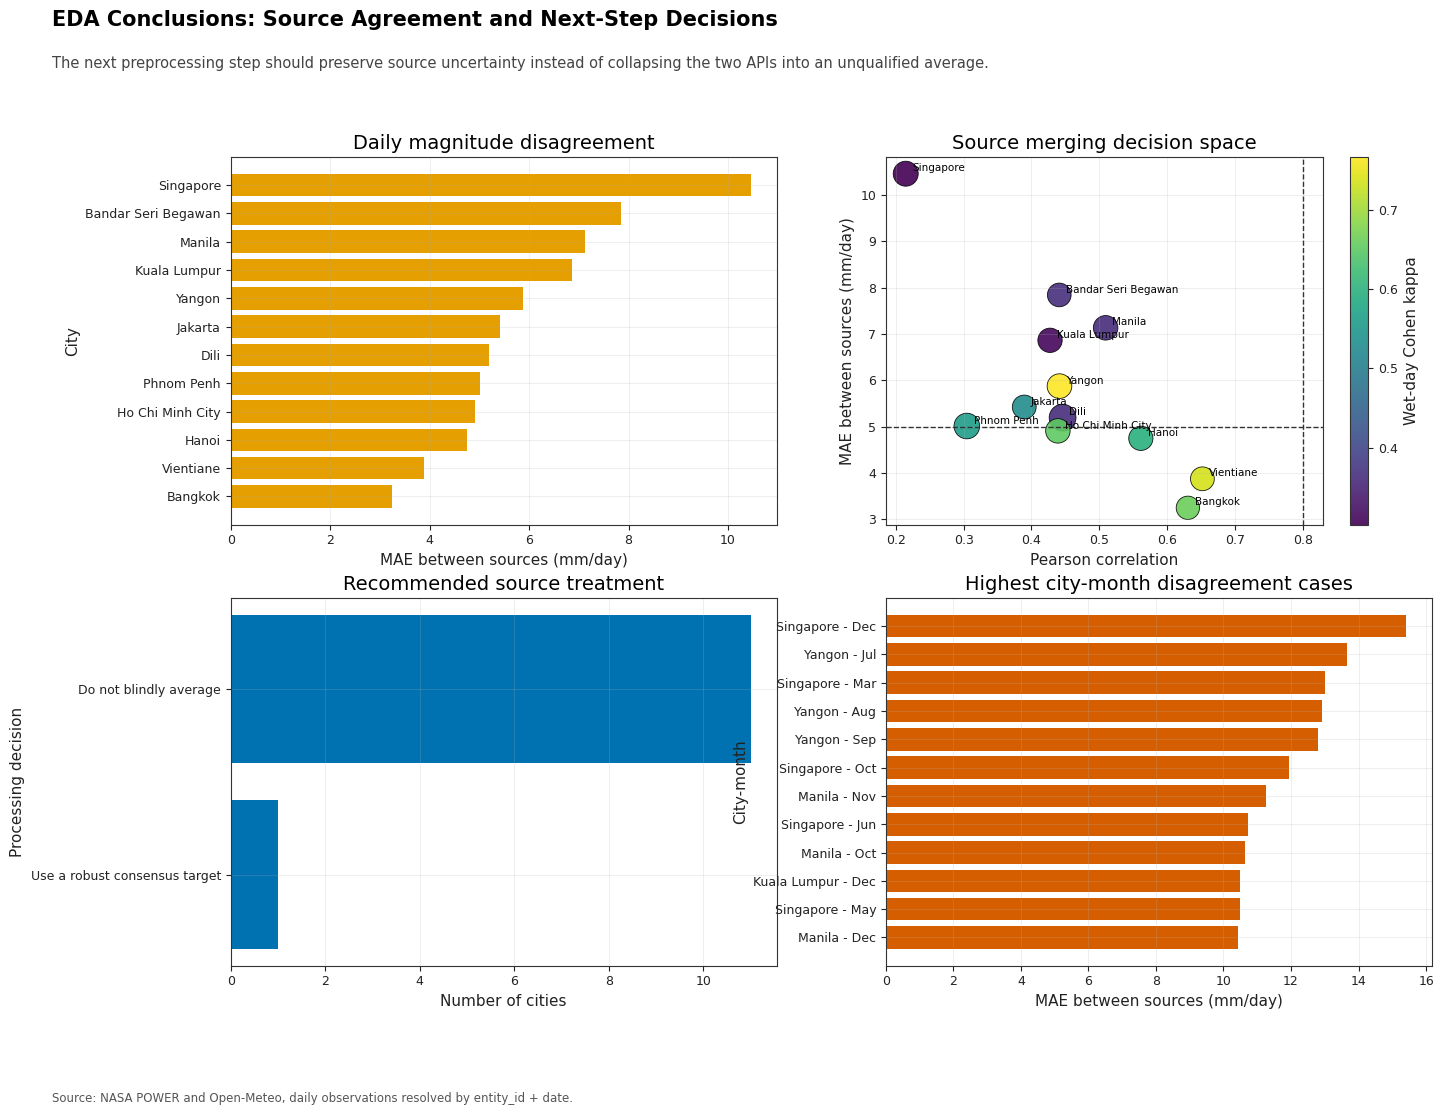

In [15]:
agreement_metric_dictionary = pd.DataFrame([
    {
        'metric': 'bias_mm',
        'formula': 'mean(NASA_POWER_precipitation_mm - Open_Meteo_precipitation_mm)',
        'interpretation': 'Signed source offset. Positive means NASA POWER is wetter on average.',
        'processing_use': 'Detects whether city/month bias correction is needed before averaging.',
    },
    {
        'metric': 'mae_mm',
        'formula': 'mean(abs(NASA_POWER_precipitation_mm - Open_Meteo_precipitation_mm))',
        'interpretation': 'Typical daily magnitude gap between the two sources.',
        'processing_use': 'Large MAE means a simple mean can hide substantial uncertainty.',
    },
    {
        'metric': 'rmse_mm',
        'formula': 'sqrt(mean((NASA_POWER_precipitation_mm - Open_Meteo_precipitation_mm)^2))',
        'interpretation': 'Error metric that penalizes large disagreement events more than MAE.',
        'processing_use': 'Highlights extreme source conflicts that may need flags or robust targets.',
    },
    {
        'metric': 'smape_pct',
        'formula': 'mean(2 * abs(NASA - Open_Meteo) / (abs(NASA) + abs(Open_Meteo) + epsilon)) * 100',
        'interpretation': 'Scale-normalized percentage disagreement.',
        'processing_use': 'Useful because a 5 mm gap is more serious on dry days than on very wet days.',
    },
    {
        'metric': 'pearson_corr',
        'formula': 'corr(NASA_POWER_precipitation_mm, Open_Meteo_precipitation_mm)',
        'interpretation': 'Linear co-movement between daily rainfall amounts.',
        'processing_use': 'High correlation supports shared signal, but does not prove equal magnitude.',
    },
    {
        'metric': 'spearman_corr',
        'formula': 'corr(rank(NASA_POWER_precipitation_mm), rank(Open_Meteo_precipitation_mm))',
        'interpretation': 'Rank-order agreement between the two sources.',
        'processing_use': 'Checks whether both sources rank dry/wet days similarly even when magnitudes differ.',
    },
    {
        'metric': 'wet_day_agreement_pct',
        'formula': 'mean((NASA >= 1 mm) == (Open_Meteo >= 1 mm)) * 100',
        'interpretation': 'How often both sources agree on wet versus non-wet days.',
        'processing_use': 'Important if the next task predicts rain occurrence or class labels.',
    },
    {
        'metric': 'wet_day_cohen_kappa',
        'formula': '(observed wet-day agreement - expected chance agreement) / (1 - expected chance agreement)',
        'interpretation': 'Chance-corrected agreement for wet-day classification.',
        'processing_use': 'More rigorous than raw agreement when wet days are common or rare.',
    },
    {
        'metric': 'wet_day_jaccard',
        'formula': 'wet-day intersection / wet-day union',
        'interpretation': 'Overlap between the sets of wet days detected by the two sources.',
        'processing_use': 'Useful for rainfall event detection and wet-spell features.',
    },
    {
        'metric': 'mean_abs_diff_relative_to_mean',
        'formula': 'mae_mm / mean((NASA_POWER_precipitation_mm + Open_Meteo_precipitation_mm) / 2)',
        'interpretation': 'Source disagreement relative to the city rainfall scale.',
        'processing_use': 'Prevents wet cities from looking worse only because their rainfall is larger.',
    },
])
save_table(agreement_metric_dictionary, '14_source_agreement_metric_dictionary.csv')


def safe_corr(left, right, method='pearson'):
    valid = pd.DataFrame({'left': left, 'right': right}).dropna()
    if len(valid) < 3 or valid['left'].nunique() < 2 or valid['right'].nunique() < 2:
        return np.nan
    if method == 'spearman':
        return valid['left'].rank().corr(valid['right'].rank())
    return valid['left'].corr(valid['right'])


def cohen_kappa_binary(left_bool, right_bool):
    valid = pd.DataFrame({'left': left_bool, 'right': right_bool}).dropna()
    if len(valid) == 0:
        return np.nan
    observed = (valid['left'] == valid['right']).mean()
    p_left_yes = valid['left'].mean()
    p_right_yes = valid['right'].mean()
    expected = p_left_yes * p_right_yes + (1 - p_left_yes) * (1 - p_right_yes)
    if np.isclose(expected, 1.0):
        return np.nan
    return (observed - expected) / (1 - expected)


def jaccard_binary(left_bool, right_bool):
    valid = pd.DataFrame({'left': left_bool, 'right': right_bool}).dropna()
    if len(valid) == 0:
        return np.nan
    intersection = (valid['left'] & valid['right']).sum()
    union = (valid['left'] | valid['right']).sum()
    return 1.0 if union == 0 else intersection / union


def compute_source_similarity(frame):
    valid = frame[['nasa_power_precipitation_mm', 'open_meteo_precipitation_mm']].dropna()
    if valid.empty:
        return pd.Series({
            'valid_pairs': 0,
            'bias_mm': np.nan,
            'mae_mm': np.nan,
            'rmse_mm': np.nan,
            'smape_pct': np.nan,
            'pearson_corr': np.nan,
            'spearman_corr': np.nan,
            'wet_day_agreement_pct': np.nan,
            'wet_day_cohen_kappa': np.nan,
            'wet_day_jaccard': np.nan,
            'mean_daily_rainfall_mm': np.nan,
            'mean_abs_diff_relative_to_mean': np.nan,
            'high_gap_10mm_ratio': np.nan,
            'high_gap_20mm_ratio': np.nan,
        })

    nasa = valid['nasa_power_precipitation_mm'].astype(float)
    open_meteo = valid['open_meteo_precipitation_mm'].astype(float)
    diff = nasa - open_meteo
    abs_diff = diff.abs()
    source_mean = (nasa + open_meteo) / 2
    wet_nasa = nasa >= 1.0
    wet_open_meteo = open_meteo >= 1.0
    mean_daily_rainfall = source_mean.mean()

    return pd.Series({
        'valid_pairs': int(len(valid)),
        'bias_mm': diff.mean(),
        'mae_mm': abs_diff.mean(),
        'rmse_mm': np.sqrt((diff ** 2).mean()),
        'smape_pct': (2 * abs_diff / (nasa.abs() + open_meteo.abs() + 1e-9)).mean() * 100,
        'pearson_corr': safe_corr(nasa, open_meteo, method='pearson'),
        'spearman_corr': safe_corr(nasa, open_meteo, method='spearman'),
        'wet_day_agreement_pct': (wet_nasa == wet_open_meteo).mean() * 100,
        'wet_day_cohen_kappa': cohen_kappa_binary(wet_nasa, wet_open_meteo),
        'wet_day_jaccard': jaccard_binary(wet_nasa, wet_open_meteo),
        'mean_daily_rainfall_mm': mean_daily_rainfall,
        'mean_abs_diff_relative_to_mean': abs_diff.mean() / (mean_daily_rainfall + 1e-9),
        'high_gap_10mm_ratio': (abs_diff > 10).mean(),
        'high_gap_20mm_ratio': (abs_diff > 20).mean(),
    })


def recommend_source_treatment(row):
    pearson = row['pearson_corr'] if pd.notna(row['pearson_corr']) else -np.inf
    kappa = row['wet_day_cohen_kappa'] if pd.notna(row['wet_day_cohen_kappa']) else -np.inf
    relative_mae = row['mean_abs_diff_relative_to_mean'] if pd.notna(row['mean_abs_diff_relative_to_mean']) else np.inf
    mae = row['mae_mm'] if pd.notna(row['mae_mm']) else np.inf
    bias = row['bias_mm'] if pd.notna(row['bias_mm']) else np.inf

    if row['valid_pairs'] < 365:
        decision = 'Insufficient paired evidence'
        target_strategy = 'Do not merge sources until paired coverage is repaired.'
        rationale = 'There are too few paired daily observations to quantify source behavior reliably.'
    elif pearson >= 0.80 and kappa >= 0.60 and relative_mae <= 0.35 and mae <= 5:
        decision = 'Average is acceptable with uncertainty features'
        target_strategy = 'Use the two-source mean as a target candidate, but keep both original source columns and source-gap features.'
        rationale = 'The sources are strongly aligned in rainfall amount and wet-day classification.'
    elif abs(bias) <= 2 and pearson >= 0.65 and kappa >= 0.45:
        decision = 'Bias-correct before averaging'
        target_strategy = 'Estimate city-month bias correction, then average corrected values and keep source-gap indicators.'
        rationale = 'The sources move together, but systematic or seasonal offset may still bias the target.'
    elif pearson < 0.45 or kappa < 0.30 or relative_mae > 0.75:
        decision = 'Do not blindly average'
        target_strategy = 'Keep NASA POWER and Open-Meteo as separate target candidates/features; choose a primary target using validation or external station ground truth.'
        rationale = 'The disagreement is large enough that a simple mean may hide real uncertainty.'
    else:
        decision = 'Use a robust consensus target'
        target_strategy = 'Use a robust consensus target with uncertainty flags, then test sensitivity against single-source targets.'
        rationale = 'Agreement is moderate; averaging can be useful only if uncertainty is exposed to later models.'

    return pd.Series({'processing_decision': decision, 'target_strategy': target_strategy, 'rationale': rationale})


global_similarity = compute_source_similarity(eda_df).to_frame().T
global_similarity.insert(0, 'scope', 'all_cities_all_days')

similarity_by_city = (
    eda_df.groupby(['entity_id', 'country', 'location_name'])
    .apply(compute_source_similarity)
    .reset_index()
    .sort_values(['mae_mm', 'mean_abs_diff_relative_to_mean'], ascending=False)
)

similarity_by_city_month = (
    eda_df.groupby(['entity_id', 'country', 'location_name', 'month'])
    .apply(compute_source_similarity)
    .reset_index()
    .sort_values(['location_name', 'month'])
)
similarity_by_city_month['month_name'] = similarity_by_city_month['month'].map(lambda month: MONTH_LABELS[month - 1])

processing_recommendations = similarity_by_city.join(
    similarity_by_city.apply(recommend_source_treatment, axis=1)
)
recommendation_counts = (
    processing_recommendations['processing_decision']
    .value_counts()
    .rename_axis('processing_decision')
    .reset_index(name='city_count')
)

save_table(global_similarity, '15_source_similarity_metrics_global.csv')
save_table(similarity_by_city, '16_source_similarity_metrics_by_city.csv')
save_table(similarity_by_city_month, '17_source_similarity_metrics_by_city_month.csv')
save_table(processing_recommendations, '18_source_processing_recommendations_by_city.csv')

wettest_city = city_summary.iloc[0]
driest_city = city_summary.sort_values('total_precip_2020_2025_mm', ascending=True).iloc[0]
most_persistent_city = city_summary.sort_values('wet_day_ratio', ascending=False).iloc[0]
highest_source_gap_city = similarity_by_city.iloc[0]
global_metrics = global_similarity.iloc[0]
direct_average_count = int((processing_recommendations['processing_decision'] == 'Average is acceptable with uncertainty features').sum())
do_not_average_count = int((processing_recommendations['processing_decision'] == 'Do not blindly average').sum())

eda_executive_summary = pd.DataFrame([
    {
        'topic': 'Coverage',
        'result': f"{len(eda_df):,} entity-date rows across {eda_df['entity_id'].nunique()} canonical locations from {eda_df['date'].min().date()} to {eda_df['date'].max().date()}.",
        'implication': 'The dataset is wide enough for city-level daily rainfall preprocessing and temporal validation.',
    },
    {
        'topic': 'Data quality',
        'result': f"{int(quality_checks['passed'].sum())}/{len(quality_checks)} core quality checks passed; negative rainfall and duplicate key counts are zero.",
        'implication': 'The next notebook can focus on modeling-oriented preprocessing rather than basic data repair.',
    },
    {
        'topic': 'Rainfall burden',
        'result': f"{wettest_city['location_name']} is the wettest city by six-year total ({wettest_city['total_precip_2020_2025_mm']:.0f} mm); {driest_city['location_name']} is the driest ({driest_city['total_precip_2020_2025_mm']:.0f} mm).",
        'implication': 'Train/test splitting and scaling should be city-aware because rainfall regimes are not homogeneous.',
    },
    {
        'topic': 'Rainfall persistence',
        'result': f"{most_persistent_city['location_name']} has the highest wet-day ratio ({most_persistent_city['wet_day_ratio']:.1%}).",
        'implication': 'Wet/dry spell features and lag features should be retained for forecasting tasks.',
    },
    {
        'topic': 'Global source agreement',
        'result': f"NASA POWER vs Open-Meteo global MAE={global_metrics['mae_mm']:.2f} mm/day, RMSE={global_metrics['rmse_mm']:.2f} mm/day, Pearson={global_metrics['pearson_corr']:.2f}, wet-day kappa={global_metrics['wet_day_cohen_kappa']:.2f}.",
        'implication': 'The two APIs share signal but still disagree enough that the target needs uncertainty-aware treatment.',
    },
    {
        'topic': 'Worst source disagreement',
        'result': f"{highest_source_gap_city['location_name']} has the largest source MAE ({highest_source_gap_city['mae_mm']:.2f} mm/day).",
        'implication': 'Cities with high disagreement need source-specific diagnostics or external validation before final target construction.',
    },
    {
        'topic': 'Averaging decision',
        'result': f"{direct_average_count}/{len(processing_recommendations)} cities pass the strict direct-averaging rule; {do_not_average_count}/{len(processing_recommendations)} are flagged as do-not-blindly-average.",
        'implication': 'Do not use the simple arithmetic mean as the final universal target without bias correction or sensitivity checks.',
    },
])
save_table(eda_executive_summary, '19_eda_executive_summary.csv')

next_step_plan = pd.DataFrame([
    {
        'next_notebook': '03_preprocessing',
        'action': 'Keep source-specific rainfall columns, the two-source mean, source bias, source absolute gap, and wet-day disagreement flags.',
        'reason': 'Agreement is not strong enough to collapse all evidence into one unqualified rainfall target.',
        'expected_output': 'A processed dataset with source-specific features and uncertainty indicators.',
    },
    {
        'next_notebook': '03_preprocessing',
        'action': 'Create at least three target candidates: NASA POWER rainfall, Open-Meteo rainfall, and a bias-corrected two-source consensus.',
        'reason': 'Target sensitivity analysis is safer than assuming one source or a raw mean is correct.',
        'expected_output': 'Comparable target columns for later validation.',
    },
    {
        'next_notebook': '03_preprocessing',
        'action': 'Estimate city-month source bias and apply calibration only where diagnostics support it.',
        'reason': 'EDA shows disagreement can vary by city and month, so one global correction would be too crude.',
        'expected_output': 'City-month correction table and calibrated rainfall candidate.',
    },
    {
        'next_notebook': '03_preprocessing',
        'action': 'Use temporal validation splits such as train=2020-2023, validation=2024, test=2025.',
        'reason': 'Random splits leak temporal structure and overstate forecasting performance.',
        'expected_output': 'Leakage-resistant train/validation/test partitions.',
    },
    {
        'next_notebook': '03_preprocessing',
        'action': 'Scale continuous predictors within training folds and keep rainfall thresholds as physically meaningful flags.',
        'reason': 'Rainfall is skewed and seasonal; preprocessing should preserve physical interpretability.',
        'expected_output': 'Model-ready numerical features with documented transformations.',
    },
    {
        'next_notebook': '04_modeling_or_benchmark_dataset',
        'action': 'Evaluate models against multiple target candidates and report whether conclusions change by target source.',
        'reason': 'A robust benchmark should show sensitivity to source uncertainty, not hide it.',
        'expected_output': 'Benchmark report with target-source sensitivity analysis.',
    },
])
save_table(next_step_plan, '20_next_step_preprocessing_plan.csv')

summary_lines = [
    '# EDA Conclusions and Next-Step Plan',
    '',
    '## Main EDA Results',
    f"- Coverage: {len(eda_df):,} daily entity-date rows, {eda_df['entity_id'].nunique()} canonical locations, {eda_df['date'].min().date()} to {eda_df['date'].max().date()}.",
    f"- Wettest city by total rainfall: {wettest_city['location_name']} ({wettest_city['total_precip_2020_2025_mm']:.0f} mm).",
    f"- Driest city by total rainfall: {driest_city['location_name']} ({driest_city['total_precip_2020_2025_mm']:.0f} mm).",
    f"- Highest wet-day persistence: {most_persistent_city['location_name']} ({most_persistent_city['wet_day_ratio']:.1%}).",
    '',
    '## Source Agreement',
    f"- Global MAE: {global_metrics['mae_mm']:.2f} mm/day.",
    f"- Global RMSE: {global_metrics['rmse_mm']:.2f} mm/day.",
    f"- Global Pearson correlation: {global_metrics['pearson_corr']:.2f}.",
    f"- Global wet-day Cohen kappa: {global_metrics['wet_day_cohen_kappa']:.2f}.",
    f"- Highest city-level source disagreement: {highest_source_gap_city['location_name']} ({highest_source_gap_city['mae_mm']:.2f} mm/day MAE).",
    '',
    '## Processing Decision',
    f"- Strict direct averaging is supported for {direct_average_count}/{len(processing_recommendations)} cities.",
    f"- Do-not-blindly-average is triggered for {do_not_average_count}/{len(processing_recommendations)} cities.",
    '- Recommended strategy: keep both sources, create uncertainty features, calibrate by city-month where justified, and compare multiple target candidates.',
    '',
    '## Next Notebook',
    '- Build `03_preprocessing.ipynb` around target sensitivity, city/month bias correction, temporal splits, and model-ready feature tables.',
]
summary_path = REPORT_DIR / 'EDA_CONCLUSIONS_AND_NEXT_STEPS.md'
summary_path.write_text('\n'.join(summary_lines), encoding='utf-8')
print(f'Saved narrative summary: {summary_path.relative_to(PROJECT_ROOT)}')

display(agreement_metric_dictionary)
display(global_similarity)
display(processing_recommendations)
display(eda_executive_summary)
display(next_step_plan)

fig, axes = plt.subplots(2, 2, figsize=(15.5, 10.5))
ordered = similarity_by_city.sort_values('mae_mm', ascending=True)
axes[0, 0].barh(ordered['location_name'], ordered['mae_mm'], color='#E69F00')
axes[0, 0].set_xlabel('MAE between sources (mm/day)')
axes[0, 0].set_ylabel('City')
axes[0, 0].set_title('Daily magnitude disagreement')

scatter = axes[0, 1].scatter(
    processing_recommendations['pearson_corr'],
    processing_recommendations['mae_mm'],
    c=processing_recommendations['wet_day_cohen_kappa'],
    s=120 + processing_recommendations['mean_abs_diff_relative_to_mean'].clip(0, 2) * 220,
    cmap='viridis',
    edgecolor='black',
    linewidth=0.6,
    alpha=0.9,
)
for _, row in processing_recommendations.iterrows():
    axes[0, 1].text(row['pearson_corr'] + 0.01, row['mae_mm'] + 0.05, row['location_name'], fontsize=7.5)
axes[0, 1].axvline(0.80, color='#333333', linestyle='--', linewidth=1)
axes[0, 1].axhline(5, color='#333333', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Pearson correlation')
axes[0, 1].set_ylabel('MAE between sources (mm/day)')
axes[0, 1].set_title('Source merging decision space')
fig.colorbar(scatter, ax=axes[0, 1], label='Wet-day Cohen kappa')

decision_order = recommendation_counts.sort_values('city_count', ascending=True)
axes[1, 0].barh(decision_order['processing_decision'], decision_order['city_count'], color='#0072B2')
axes[1, 0].set_xlabel('Number of cities')
axes[1, 0].set_ylabel('Processing decision')
axes[1, 0].set_title('Recommended source treatment')

top_monthly_gap = (
    similarity_by_city_month.sort_values('mae_mm', ascending=False)
    .head(12)
    .assign(city_month=lambda df: df['location_name'] + ' - ' + df['month_name'])
    .sort_values('mae_mm', ascending=True)
)
axes[1, 1].barh(top_monthly_gap['city_month'], top_monthly_gap['mae_mm'], color='#D55E00')
axes[1, 1].set_xlabel('MAE between sources (mm/day)')
axes[1, 1].set_ylabel('City-month')
axes[1, 1].set_title('Highest city-month disagreement cases')

add_title(fig, 'EDA Conclusions: Source Agreement and Next-Step Decisions', 'The next preprocessing step should preserve source uncertainty instead of collapsing the two APIs into an unqualified average.')
add_source_note(fig)
save_figure(fig, '20_eda_agreement_and_next_steps_summary.png')
plt.show()
plt.close(fig)